In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dask
import zarr
import xarray as xr
import cftime
import os

In [2]:
llc_path = '/orcd/data/abodner/002/cody/LLC_patch/LLC4320_face1_i2880-3600_j720-1440.zarr'
llc_patch_full = xr.open_dataset(llc_path, consolidated=True)

In [3]:
llc_sub = llc_patch_full.isel(time=slice(9240,9240+168),k=0)

Generating plots for Theta...


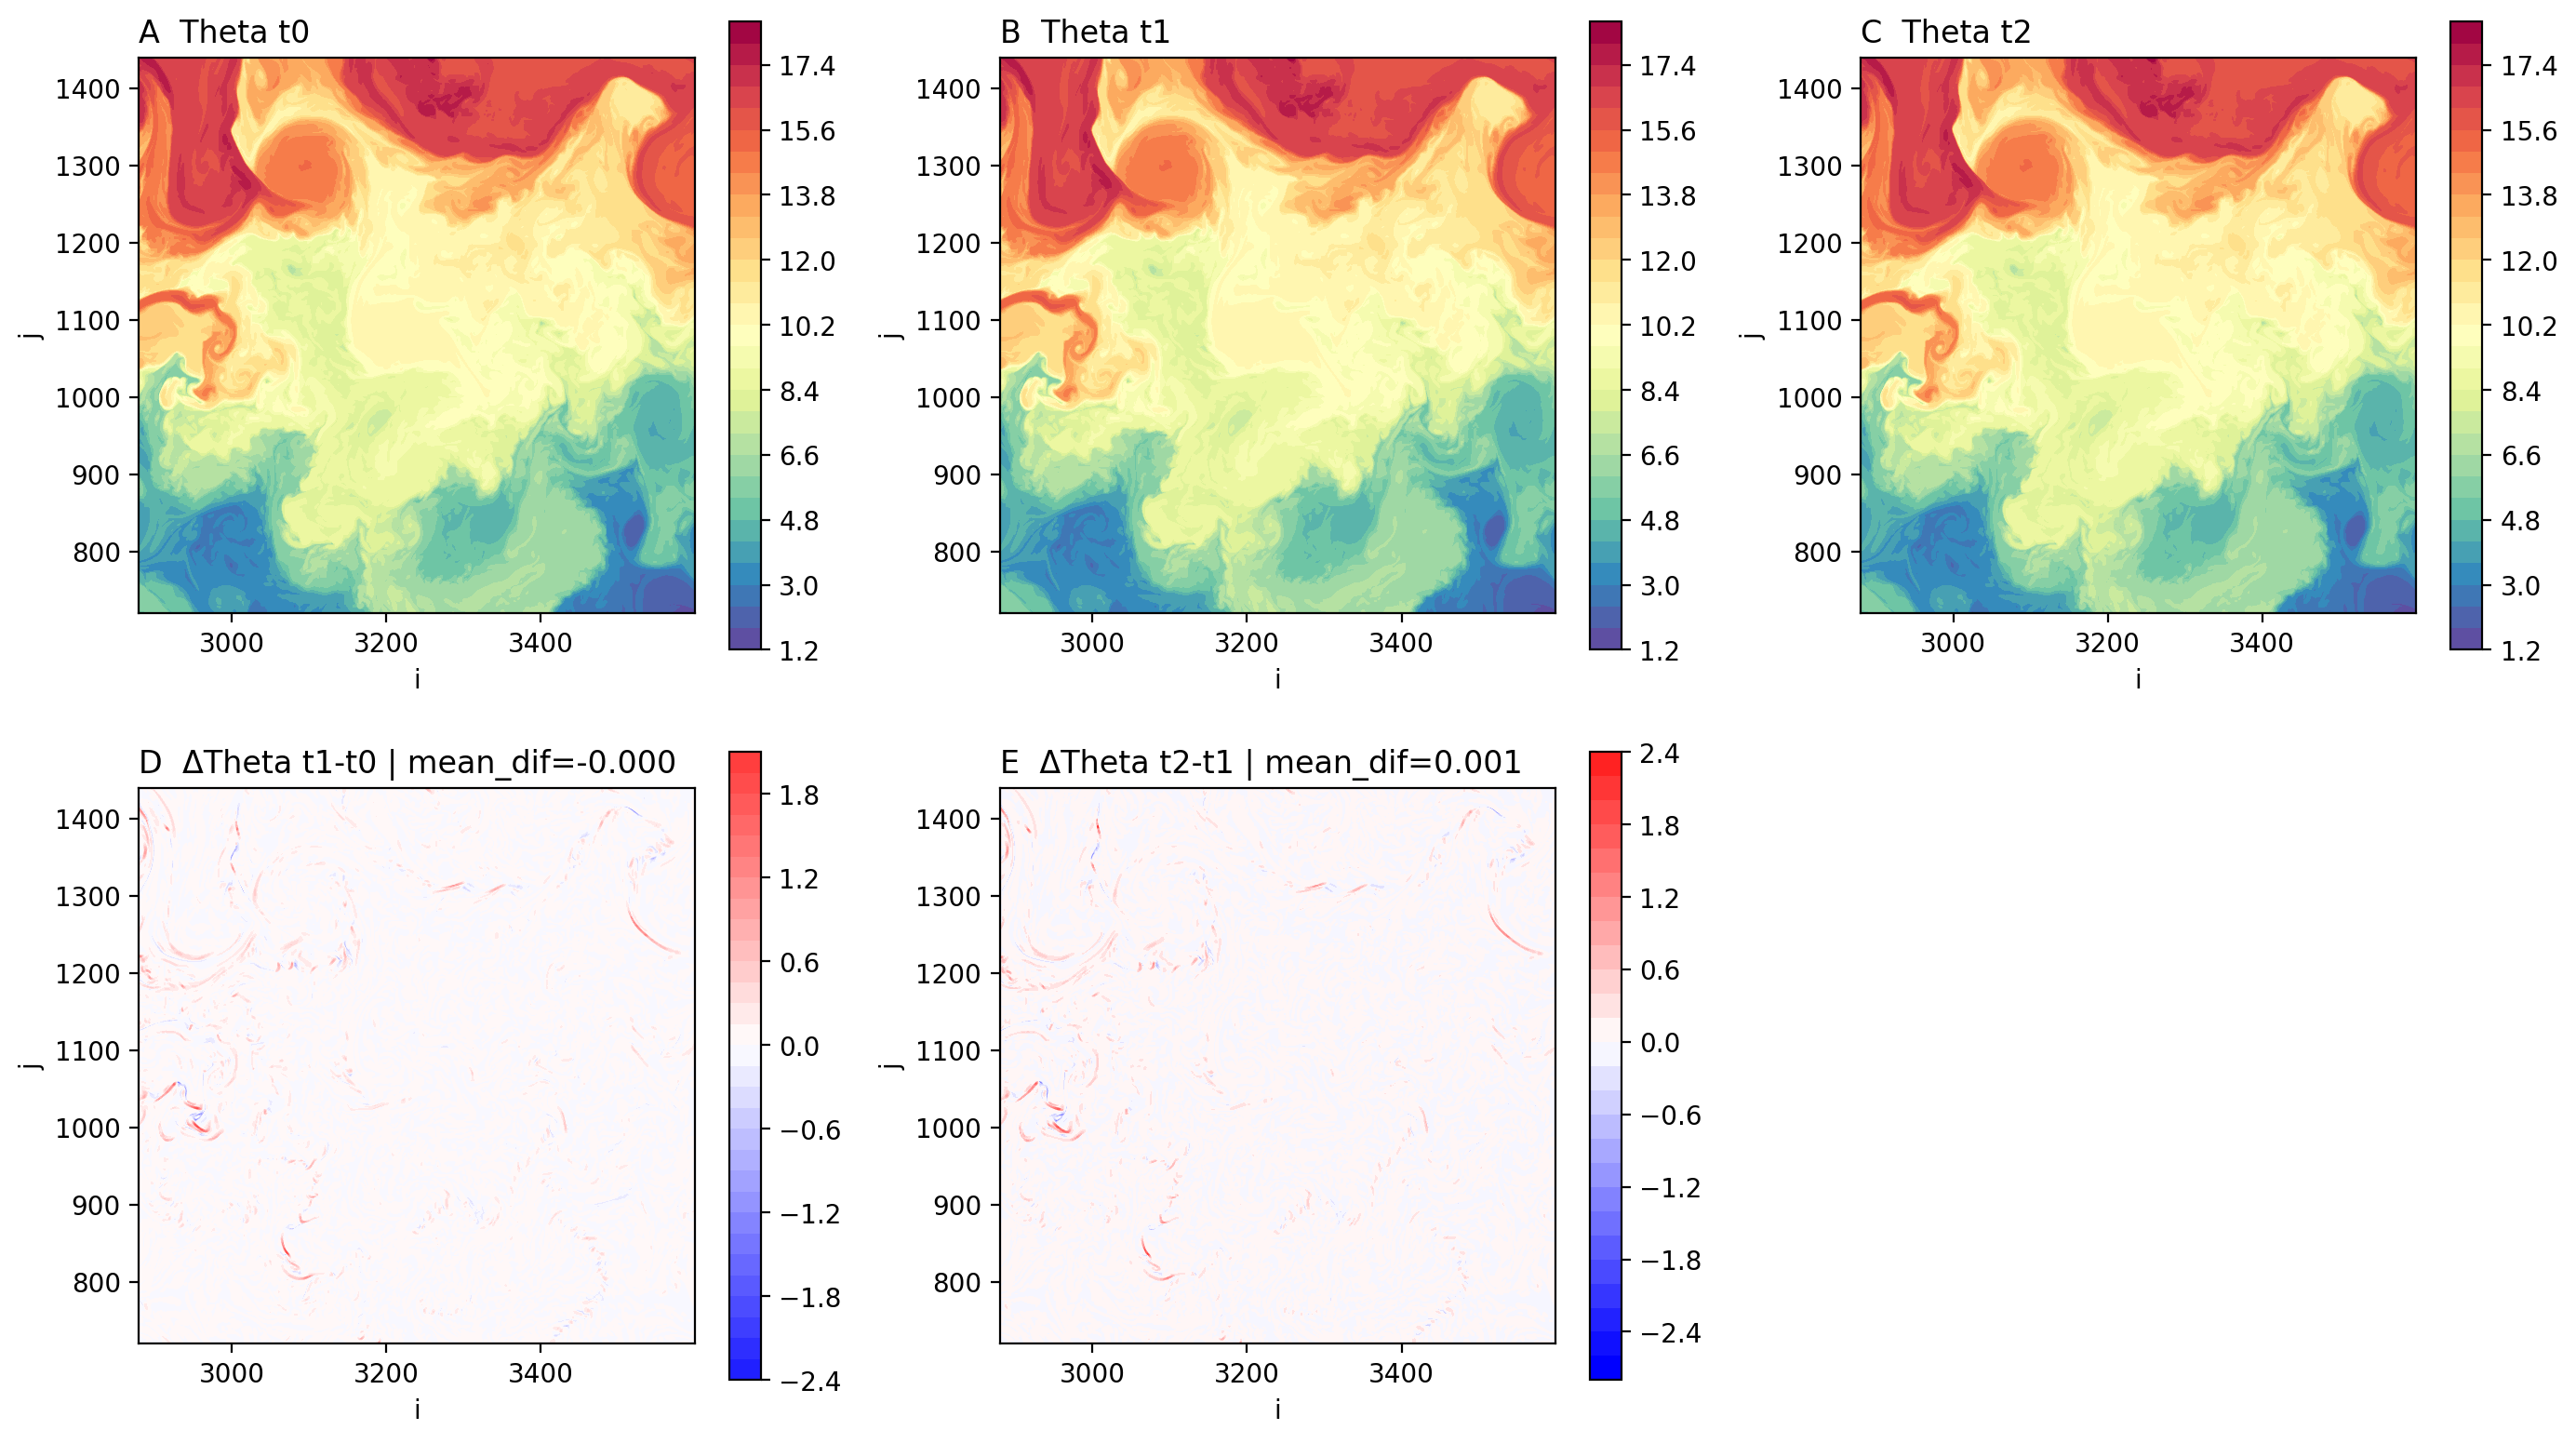

In [4]:
vars = ['Theta']
colormaps = {'Theta': 'Spectral_r', 'Salt': 'viridis', 'U': 'bwr', 'V': 'bwr'}
data_stride = 1
time_0 = 0

for var in vars:
    print(f"Generating plots for {var}...")

    t0 = time_0
    t1 = time_0 + data_stride
    t2 = time_0 + 2 * data_stride

    if t2 >= len(llc_sub.time):
        raise ValueError(f"time_0 + 2*data_stride = {t2}, but only {len(llc_sub.time)} times available")

    field0 = llc_sub[var].isel(time=t0)
    field1 = llc_sub[var].isel(time=t1)
    field2 = llc_sub[var].isel(time=t2)

    diff10 = field1 - field0
    diff21 = field2 - field1

    mean_dif_10 = float(diff10.mean(skipna=True).values)
    mean_dif_21 = float(diff21.mean(skipna=True).values)

    x = field0.coords.get('i', np.arange(field0.shape[-1]))
    y = field0.coords.get('j', np.arange(field0.shape[-2]))

    cmap = colormaps.get(var, 'viridis')
    diff_cmap = cmap if cmap in ['bwr', 'seismic', 'RdBu_r'] else 'bwr'

    # robust limits
    field_vals = np.concatenate([field0.values.ravel(),
                                 field1.values.ravel(),
                                 field2.values.ravel()])
    field_vals = field_vals[np.isfinite(field_vals)]

    if len(field_vals) == 0:
        continue

    vmin, vmax = np.nanmin(field_vals), np.nanmax(field_vals)

    diff_vals = np.concatenate([diff10.values.ravel(), diff21.values.ravel()])
    diff_vals = diff_vals[np.isfinite(diff_vals)]

    if len(diff_vals) == 0:
        continue

    diff_absmax = np.nanmax(np.abs(diff_vals))

    # --- NEW LANDSCAPE LAYOUT ---
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=200)

    # --- Row 1: fields ---
    cf = axes[0, 0].contourf(x, y, field0, cmap=cmap, vmin=vmin, vmax=vmax, levels=30)
    axes[0, 0].set_title(f'A  {var} t{t0}', loc='left', fontweight='bold')
    plt.colorbar(cf, ax=axes[0, 0])

    cf = axes[0, 1].contourf(x, y, field1, cmap=cmap, vmin=vmin, vmax=vmax, levels=30)
    axes[0, 1].set_title(f'B  {var} t{t1}', loc='left', fontweight='bold')
    plt.colorbar(cf, ax=axes[0, 1])

    cf = axes[0, 2].contourf(x, y, field2, cmap=cmap, vmin=vmin, vmax=vmax, levels=30)
    axes[0, 2].set_title(f'C  {var} t{t2}', loc='left', fontweight='bold')
    plt.colorbar(cf, ax=axes[0, 2])

    # --- Row 2: differences ---
    cf = axes[1, 0].contourf(x, y, diff10, cmap=diff_cmap,
                             vmin=-diff_absmax, vmax=diff_absmax, levels=30)
    axes[1, 0].set_title(
        f'D  Δ{var} t{t1}-t{t0} | mean_dif={mean_dif_10:.3f}',
        loc='left', fontweight='bold'
    )
    plt.colorbar(cf, ax=axes[1, 0])

    cf = axes[1, 1].contourf(x, y, diff21, cmap=diff_cmap,
                             vmin=-diff_absmax, vmax=diff_absmax, levels=30)
    axes[1, 1].set_title(
        f'E  Δ{var} t{t2}-t{t1} | mean_dif={mean_dif_21:.3f}',
        loc='left', fontweight='bold'
    )
    plt.colorbar(cf, ax=axes[1, 1])

    # empty panel (keeps layout clean)
    axes[1, 2].axis('off')

    # formatting
    for ax in axes.flat:
        if ax.has_data():
            ax.set_xlabel('i')
            ax.set_ylabel('j')
            ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

Generating plots for Theta...


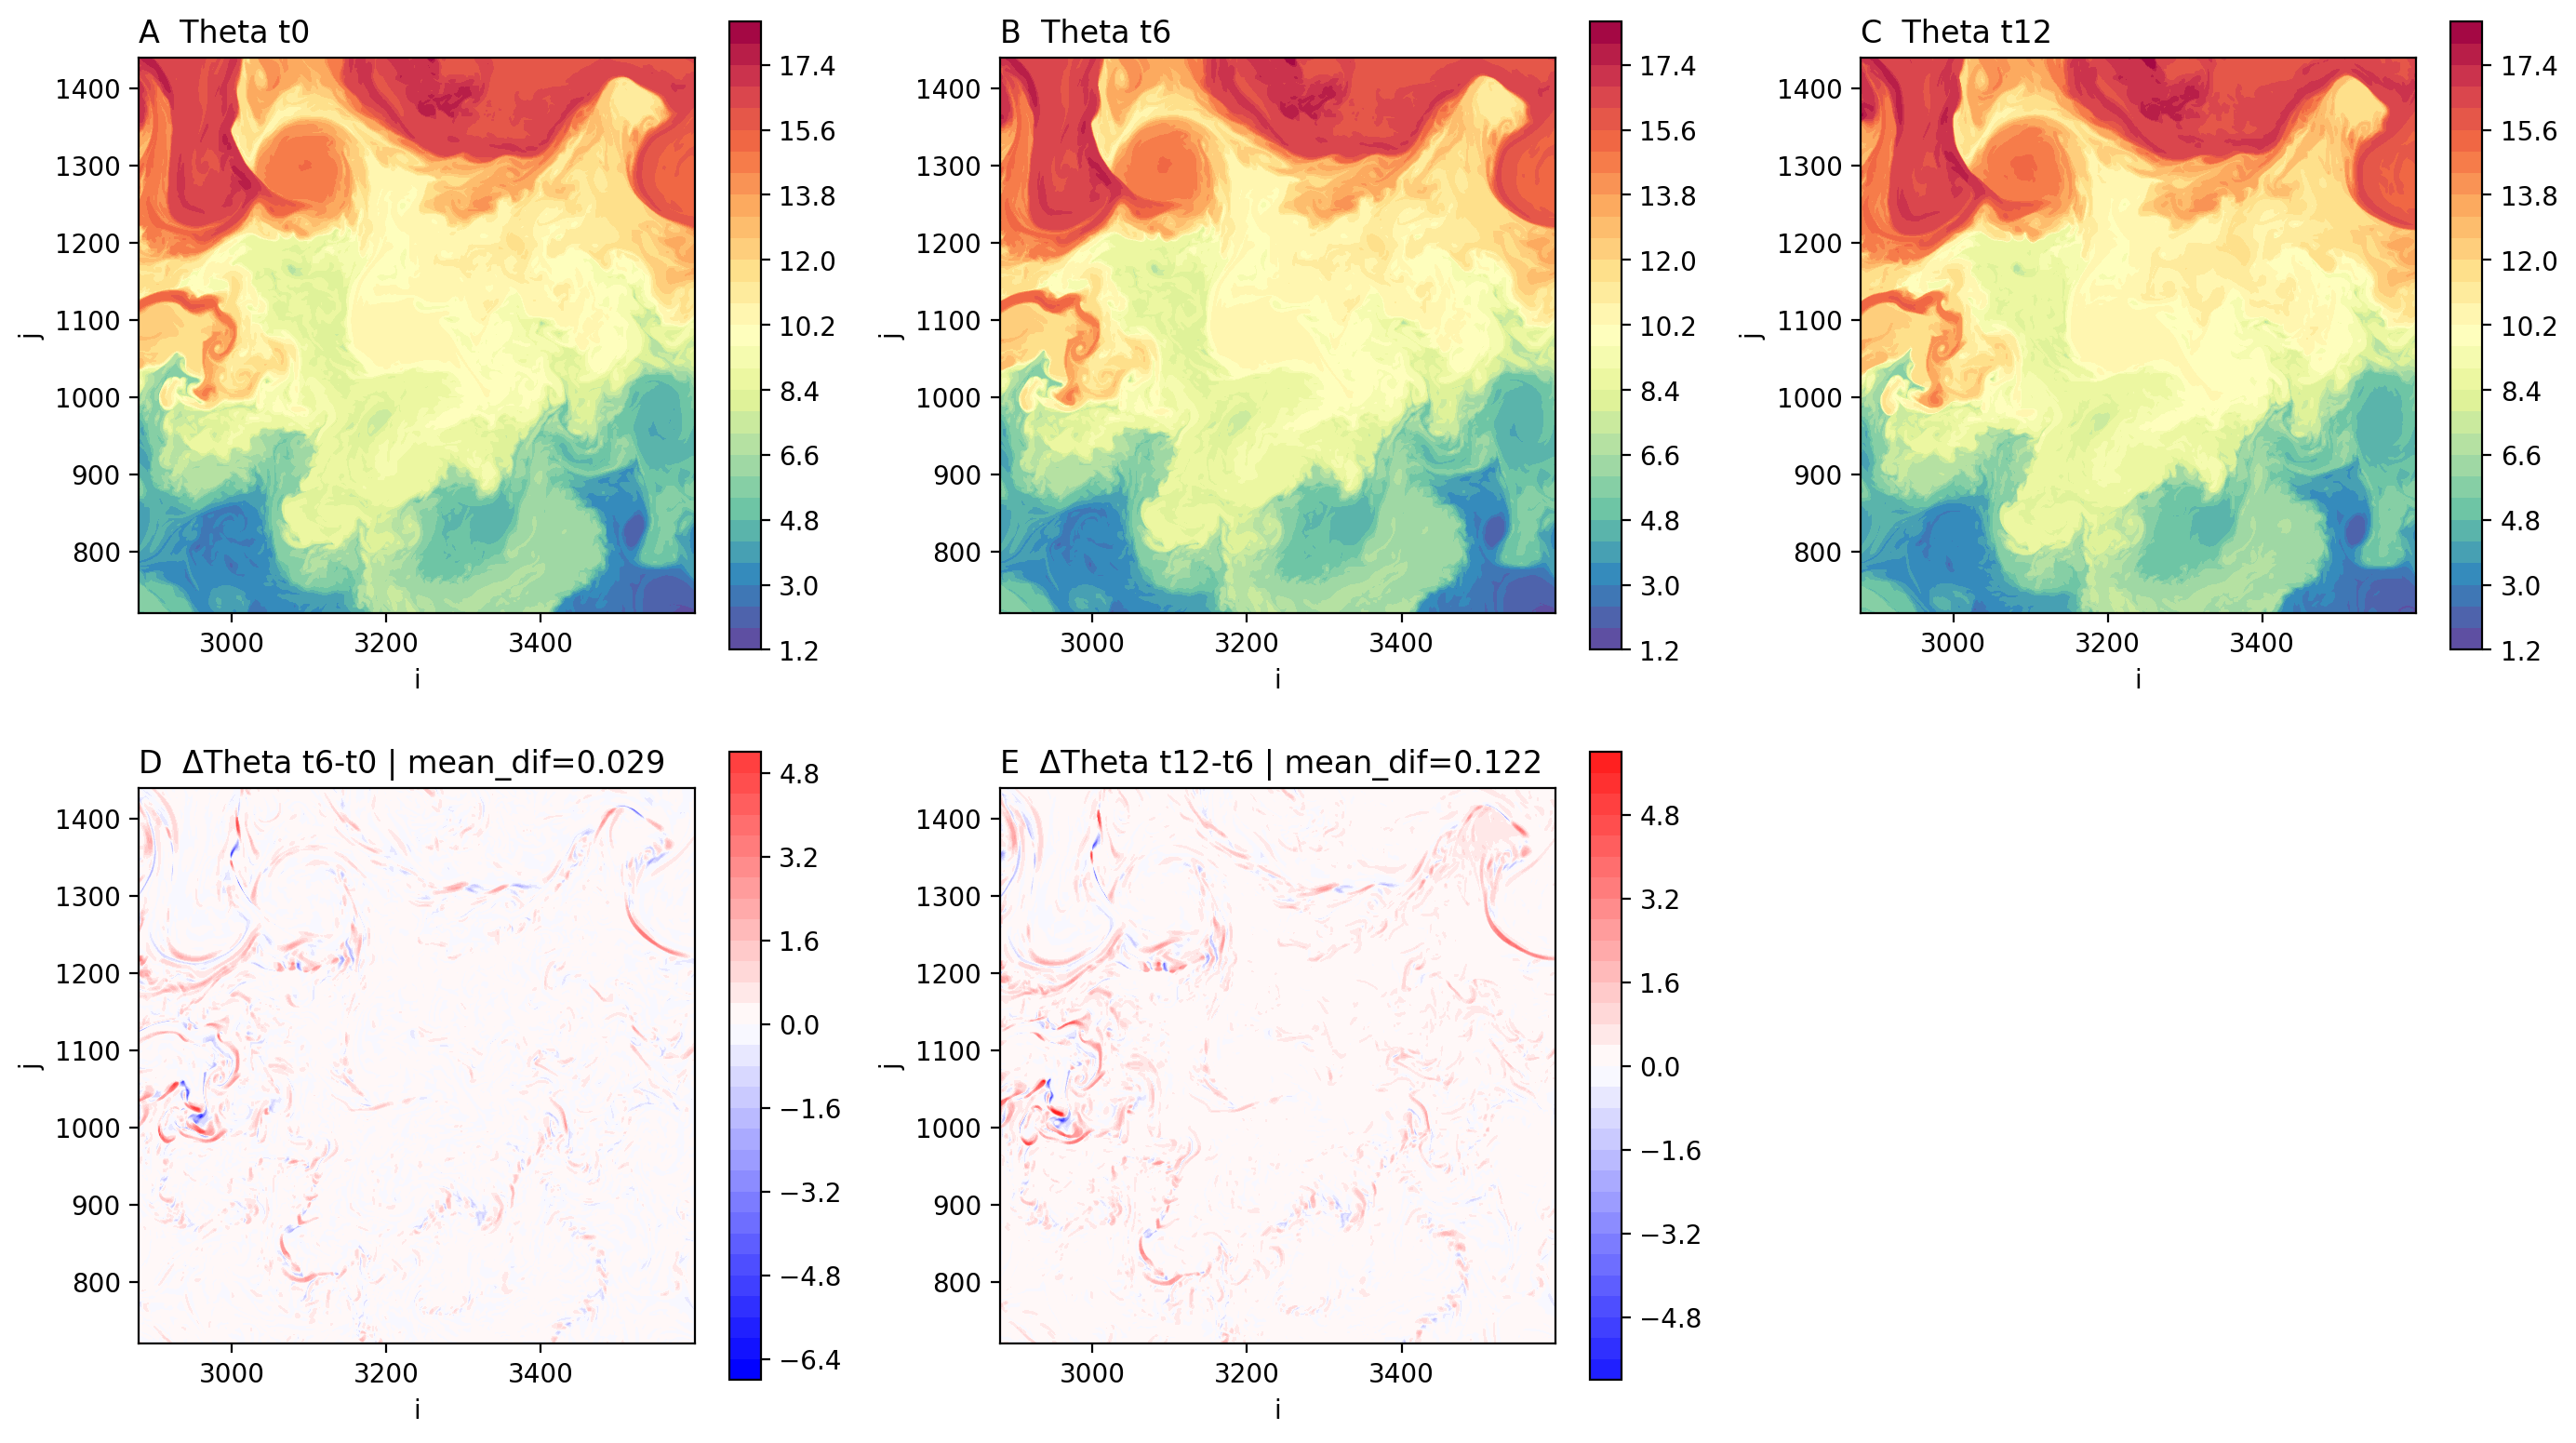

In [5]:
vars = ['Theta']
colormaps = {'Theta': 'Spectral_r', 'Salt': 'viridis', 'U': 'bwr', 'V': 'bwr'}
data_stride = 6
time_0 = 0

for var in vars:
    print(f"Generating plots for {var}...")

    t0 = time_0
    t1 = time_0 + data_stride
    t2 = time_0 + 2 * data_stride

    if t2 >= len(llc_sub.time):
        raise ValueError(f"time_0 + 2*data_stride = {t2}, but only {len(llc_sub.time)} times available")

    field0 = llc_sub[var].isel(time=t0)
    field1 = llc_sub[var].isel(time=t1)
    field2 = llc_sub[var].isel(time=t2)

    diff10 = field1 - field0
    diff21 = field2 - field1

    mean_dif_10 = float(diff10.mean(skipna=True).values)
    mean_dif_21 = float(diff21.mean(skipna=True).values)

    x = field0.coords.get('i', np.arange(field0.shape[-1]))
    y = field0.coords.get('j', np.arange(field0.shape[-2]))

    cmap = colormaps.get(var, 'viridis')
    diff_cmap = cmap if cmap in ['bwr', 'seismic', 'RdBu_r'] else 'bwr'

    # robust limits
    field_vals = np.concatenate([field0.values.ravel(),
                                 field1.values.ravel(),
                                 field2.values.ravel()])
    field_vals = field_vals[np.isfinite(field_vals)]

    if len(field_vals) == 0:
        continue

    vmin, vmax = np.nanmin(field_vals), np.nanmax(field_vals)

    diff_vals = np.concatenate([diff10.values.ravel(), diff21.values.ravel()])
    diff_vals = diff_vals[np.isfinite(diff_vals)]

    if len(diff_vals) == 0:
        continue

    diff_absmax = np.nanmax(np.abs(diff_vals))

    # --- NEW LANDSCAPE LAYOUT ---
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=200)

    # --- Row 1: fields ---
    cf = axes[0, 0].contourf(x, y, field0, cmap=cmap, vmin=vmin, vmax=vmax, levels=30)
    axes[0, 0].set_title(f'A  {var} t{t0}', loc='left', fontweight='bold')
    plt.colorbar(cf, ax=axes[0, 0])

    cf = axes[0, 1].contourf(x, y, field1, cmap=cmap, vmin=vmin, vmax=vmax, levels=30)
    axes[0, 1].set_title(f'B  {var} t{t1}', loc='left', fontweight='bold')
    plt.colorbar(cf, ax=axes[0, 1])

    cf = axes[0, 2].contourf(x, y, field2, cmap=cmap, vmin=vmin, vmax=vmax, levels=30)
    axes[0, 2].set_title(f'C  {var} t{t2}', loc='left', fontweight='bold')
    plt.colorbar(cf, ax=axes[0, 2])

    # --- Row 2: differences ---
    cf = axes[1, 0].contourf(x, y, diff10, cmap=diff_cmap,
                             vmin=-diff_absmax, vmax=diff_absmax, levels=30)
    axes[1, 0].set_title(
        f'D  Δ{var} t{t1}-t{t0} | mean_dif={mean_dif_10:.3f}',
        loc='left', fontweight='bold'
    )
    plt.colorbar(cf, ax=axes[1, 0])

    cf = axes[1, 1].contourf(x, y, diff21, cmap=diff_cmap,
                             vmin=-diff_absmax, vmax=diff_absmax, levels=30)
    axes[1, 1].set_title(
        f'E  Δ{var} t{t2}-t{t1} | mean_dif={mean_dif_21:.3f}',
        loc='left', fontweight='bold'
    )
    plt.colorbar(cf, ax=axes[1, 1])

    # empty panel (keeps layout clean)
    axes[1, 2].axis('off')

    # formatting
    for ax in axes.flat:
        if ax.has_data():
            ax.set_xlabel('i')
            ax.set_ylabel('j')
            ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

Generating plots for Theta...


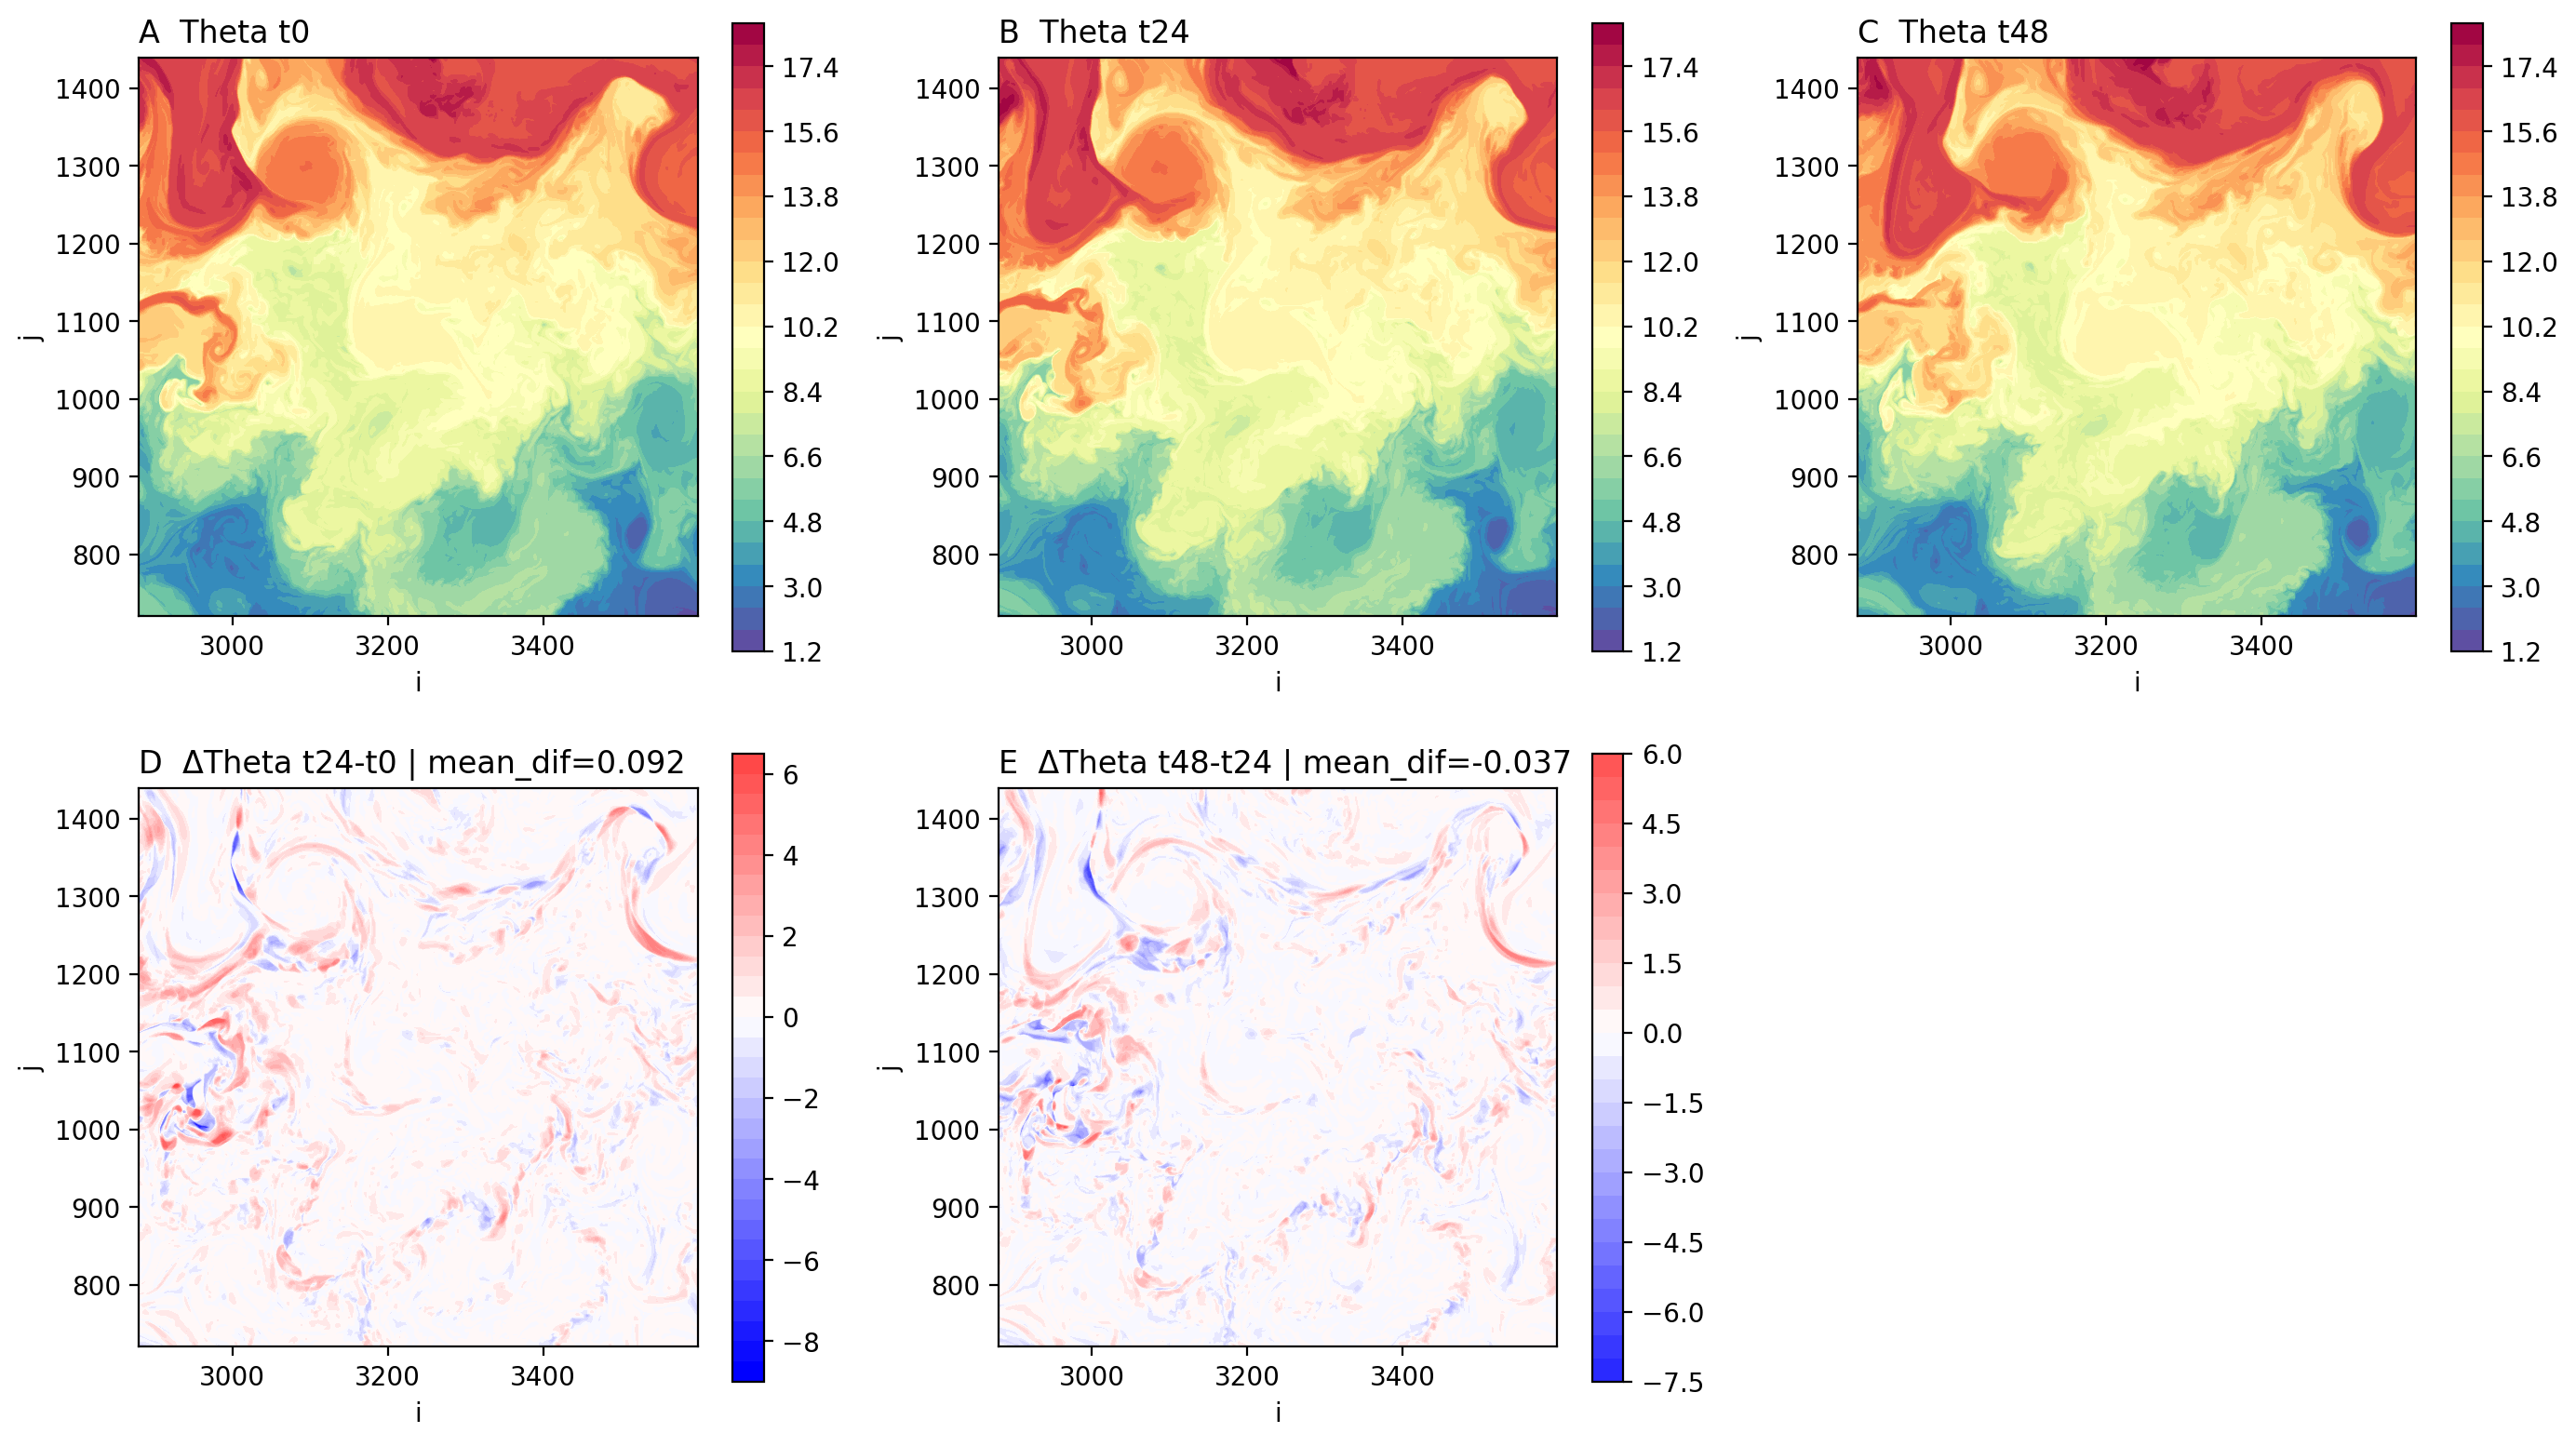

In [6]:
vars = ['Theta']
colormaps = {'Theta': 'Spectral_r', 'Salt': 'viridis', 'U': 'bwr', 'V': 'bwr'}
data_stride = 24
time_0 = 0

for var in vars:
    print(f"Generating plots for {var}...")

    t0 = time_0
    t1 = time_0 + data_stride
    t2 = time_0 + 2 * data_stride

    if t2 >= len(llc_sub.time):
        raise ValueError(f"time_0 + 2*data_stride = {t2}, but only {len(llc_sub.time)} times available")

    field0 = llc_sub[var].isel(time=t0)
    field1 = llc_sub[var].isel(time=t1)
    field2 = llc_sub[var].isel(time=t2)

    diff10 = field1 - field0
    diff21 = field2 - field1

    mean_dif_10 = float(diff10.mean(skipna=True).values)
    mean_dif_21 = float(diff21.mean(skipna=True).values)

    x = field0.coords.get('i', np.arange(field0.shape[-1]))
    y = field0.coords.get('j', np.arange(field0.shape[-2]))

    cmap = colormaps.get(var, 'viridis')
    diff_cmap = cmap if cmap in ['bwr', 'seismic', 'RdBu_r'] else 'bwr'

    # robust limits
    field_vals = np.concatenate([field0.values.ravel(),
                                 field1.values.ravel(),
                                 field2.values.ravel()])
    field_vals = field_vals[np.isfinite(field_vals)]

    if len(field_vals) == 0:
        continue

    vmin, vmax = np.nanmin(field_vals), np.nanmax(field_vals)

    diff_vals = np.concatenate([diff10.values.ravel(), diff21.values.ravel()])
    diff_vals = diff_vals[np.isfinite(diff_vals)]

    if len(diff_vals) == 0:
        continue

    diff_absmax = np.nanmax(np.abs(diff_vals))

    # --- NEW LANDSCAPE LAYOUT ---
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=200)

    # --- Row 1: fields ---
    cf = axes[0, 0].contourf(x, y, field0, cmap=cmap, vmin=vmin, vmax=vmax, levels=30)
    axes[0, 0].set_title(f'A  {var} t{t0}', loc='left', fontweight='bold')
    plt.colorbar(cf, ax=axes[0, 0])

    cf = axes[0, 1].contourf(x, y, field1, cmap=cmap, vmin=vmin, vmax=vmax, levels=30)
    axes[0, 1].set_title(f'B  {var} t{t1}', loc='left', fontweight='bold')
    plt.colorbar(cf, ax=axes[0, 1])

    cf = axes[0, 2].contourf(x, y, field2, cmap=cmap, vmin=vmin, vmax=vmax, levels=30)
    axes[0, 2].set_title(f'C  {var} t{t2}', loc='left', fontweight='bold')
    plt.colorbar(cf, ax=axes[0, 2])

    # --- Row 2: differences ---
    cf = axes[1, 0].contourf(x, y, diff10, cmap=diff_cmap,
                             vmin=-diff_absmax, vmax=diff_absmax, levels=30)
    axes[1, 0].set_title(
        f'D  Δ{var} t{t1}-t{t0} | mean_dif={mean_dif_10:.3f}',
        loc='left', fontweight='bold'
    )
    plt.colorbar(cf, ax=axes[1, 0])

    cf = axes[1, 1].contourf(x, y, diff21, cmap=diff_cmap,
                             vmin=-diff_absmax, vmax=diff_absmax, levels=30)
    axes[1, 1].set_title(
        f'E  Δ{var} t{t2}-t{t1} | mean_dif={mean_dif_21:.3f}',
        loc='left', fontweight='bold'
    )
    plt.colorbar(cf, ax=axes[1, 1])

    # empty panel (keeps layout clean)
    axes[1, 2].axis('off')

    # formatting
    for ax in axes.flat:
        if ax.has_data():
            ax.set_xlabel('i')
            ax.set_ylabel('j')
            ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

Generating plots for Theta...


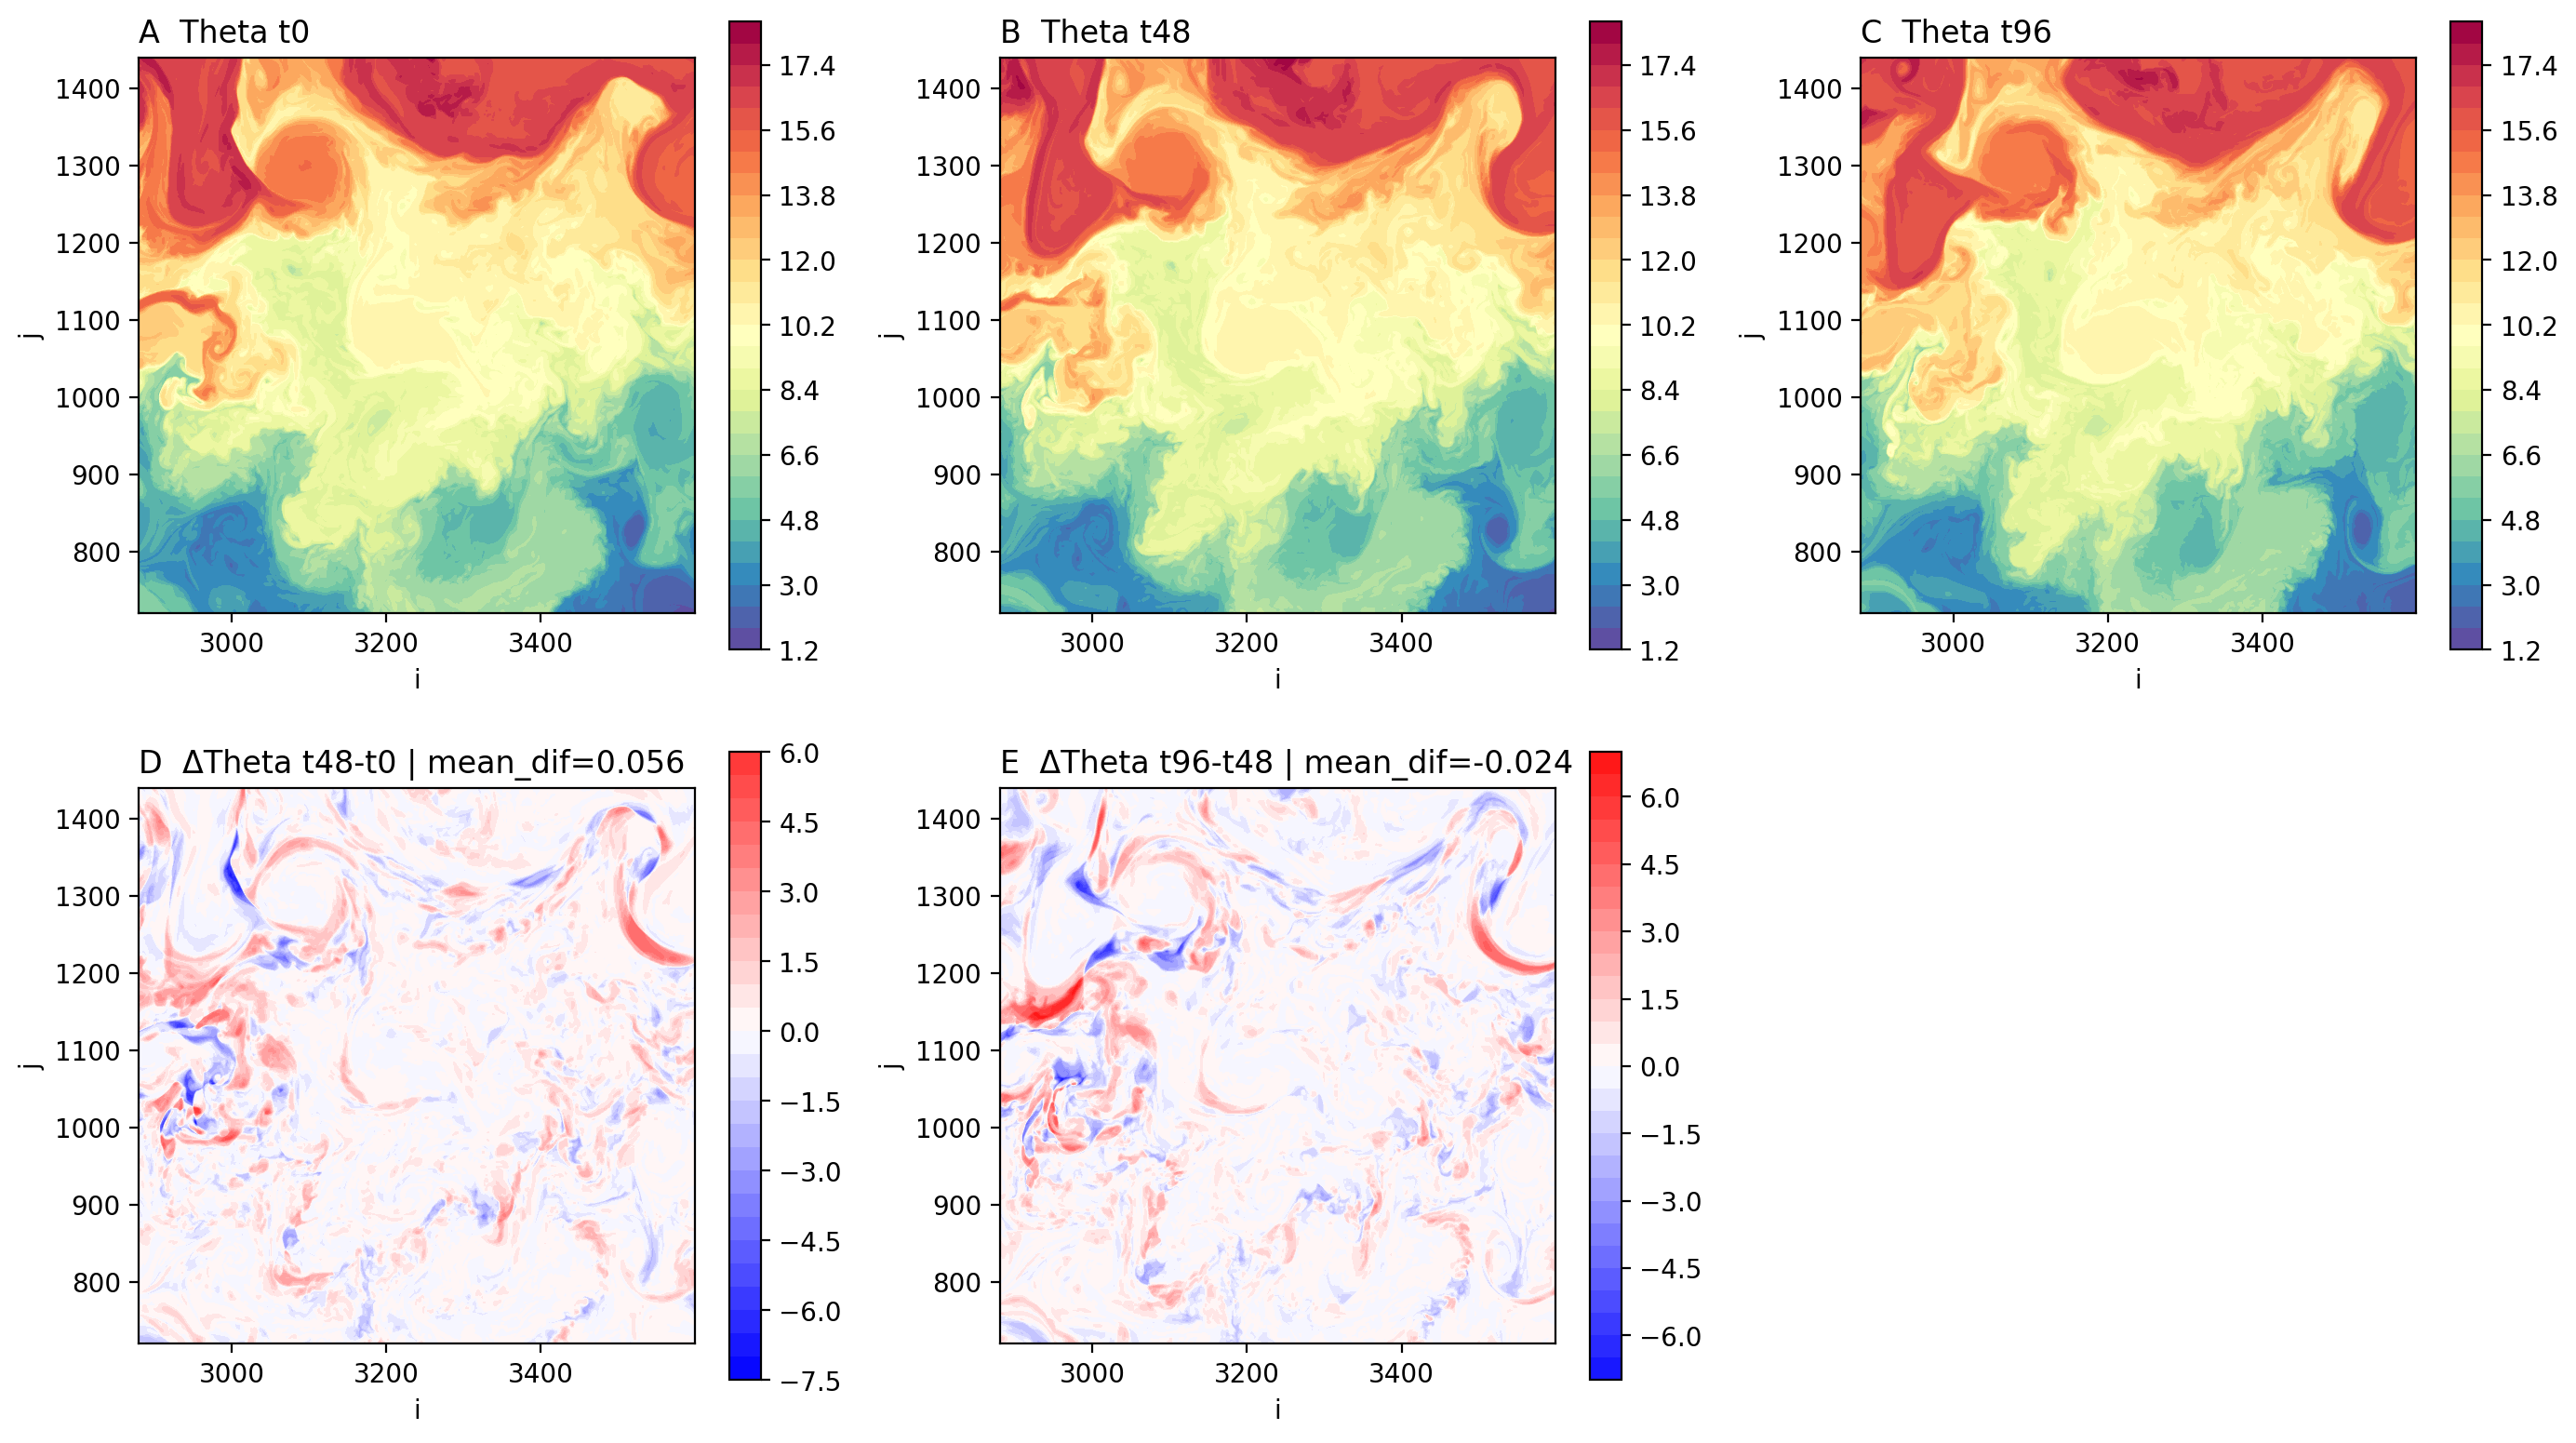

In [7]:
vars = ['Theta']
colormaps = {'Theta': 'Spectral_r', 'Salt': 'viridis', 'U': 'bwr', 'V': 'bwr'}
data_stride = 48
time_0 = 0

for var in vars:
    print(f"Generating plots for {var}...")

    t0 = time_0
    t1 = time_0 + data_stride
    t2 = time_0 + 2 * data_stride

    if t2 >= len(llc_sub.time):
        raise ValueError(f"time_0 + 2*data_stride = {t2}, but only {len(llc_sub.time)} times available")

    field0 = llc_sub[var].isel(time=t0)
    field1 = llc_sub[var].isel(time=t1)
    field2 = llc_sub[var].isel(time=t2)

    diff10 = field1 - field0
    diff21 = field2 - field1

    mean_dif_10 = float(diff10.mean(skipna=True).values)
    mean_dif_21 = float(diff21.mean(skipna=True).values)

    x = field0.coords.get('i', np.arange(field0.shape[-1]))
    y = field0.coords.get('j', np.arange(field0.shape[-2]))

    cmap = colormaps.get(var, 'viridis')
    diff_cmap = cmap if cmap in ['bwr', 'seismic', 'RdBu_r'] else 'bwr'

    # robust limits
    field_vals = np.concatenate([field0.values.ravel(),
                                 field1.values.ravel(),
                                 field2.values.ravel()])
    field_vals = field_vals[np.isfinite(field_vals)]

    if len(field_vals) == 0:
        continue

    vmin, vmax = np.nanmin(field_vals), np.nanmax(field_vals)

    diff_vals = np.concatenate([diff10.values.ravel(), diff21.values.ravel()])
    diff_vals = diff_vals[np.isfinite(diff_vals)]

    if len(diff_vals) == 0:
        continue

    diff_absmax = np.nanmax(np.abs(diff_vals))

    # --- NEW LANDSCAPE LAYOUT ---
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=200)

    # --- Row 1: fields ---
    cf = axes[0, 0].contourf(x, y, field0, cmap=cmap, vmin=vmin, vmax=vmax, levels=30)
    axes[0, 0].set_title(f'A  {var} t{t0}', loc='left', fontweight='bold')
    plt.colorbar(cf, ax=axes[0, 0])

    cf = axes[0, 1].contourf(x, y, field1, cmap=cmap, vmin=vmin, vmax=vmax, levels=30)
    axes[0, 1].set_title(f'B  {var} t{t1}', loc='left', fontweight='bold')
    plt.colorbar(cf, ax=axes[0, 1])

    cf = axes[0, 2].contourf(x, y, field2, cmap=cmap, vmin=vmin, vmax=vmax, levels=30)
    axes[0, 2].set_title(f'C  {var} t{t2}', loc='left', fontweight='bold')
    plt.colorbar(cf, ax=axes[0, 2])

    # --- Row 2: differences ---
    cf = axes[1, 0].contourf(x, y, diff10, cmap=diff_cmap,
                             vmin=-diff_absmax, vmax=diff_absmax, levels=30)
    axes[1, 0].set_title(
        f'D  Δ{var} t{t1}-t{t0} | mean_dif={mean_dif_10:.3f}',
        loc='left', fontweight='bold'
    )
    plt.colorbar(cf, ax=axes[1, 0])

    cf = axes[1, 1].contourf(x, y, diff21, cmap=diff_cmap,
                             vmin=-diff_absmax, vmax=diff_absmax, levels=30)
    axes[1, 1].set_title(
        f'E  Δ{var} t{t2}-t{t1} | mean_dif={mean_dif_21:.3f}',
        loc='left', fontweight='bold'
    )
    plt.colorbar(cf, ax=axes[1, 1])

    # empty panel (keeps layout clean)
    axes[1, 2].axis('off')

    # formatting
    for ax in axes.flat:
        if ax.has_data():
            ax.set_xlabel('i')
            ax.set_ylabel('j')
            ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

Generating plots for Theta...


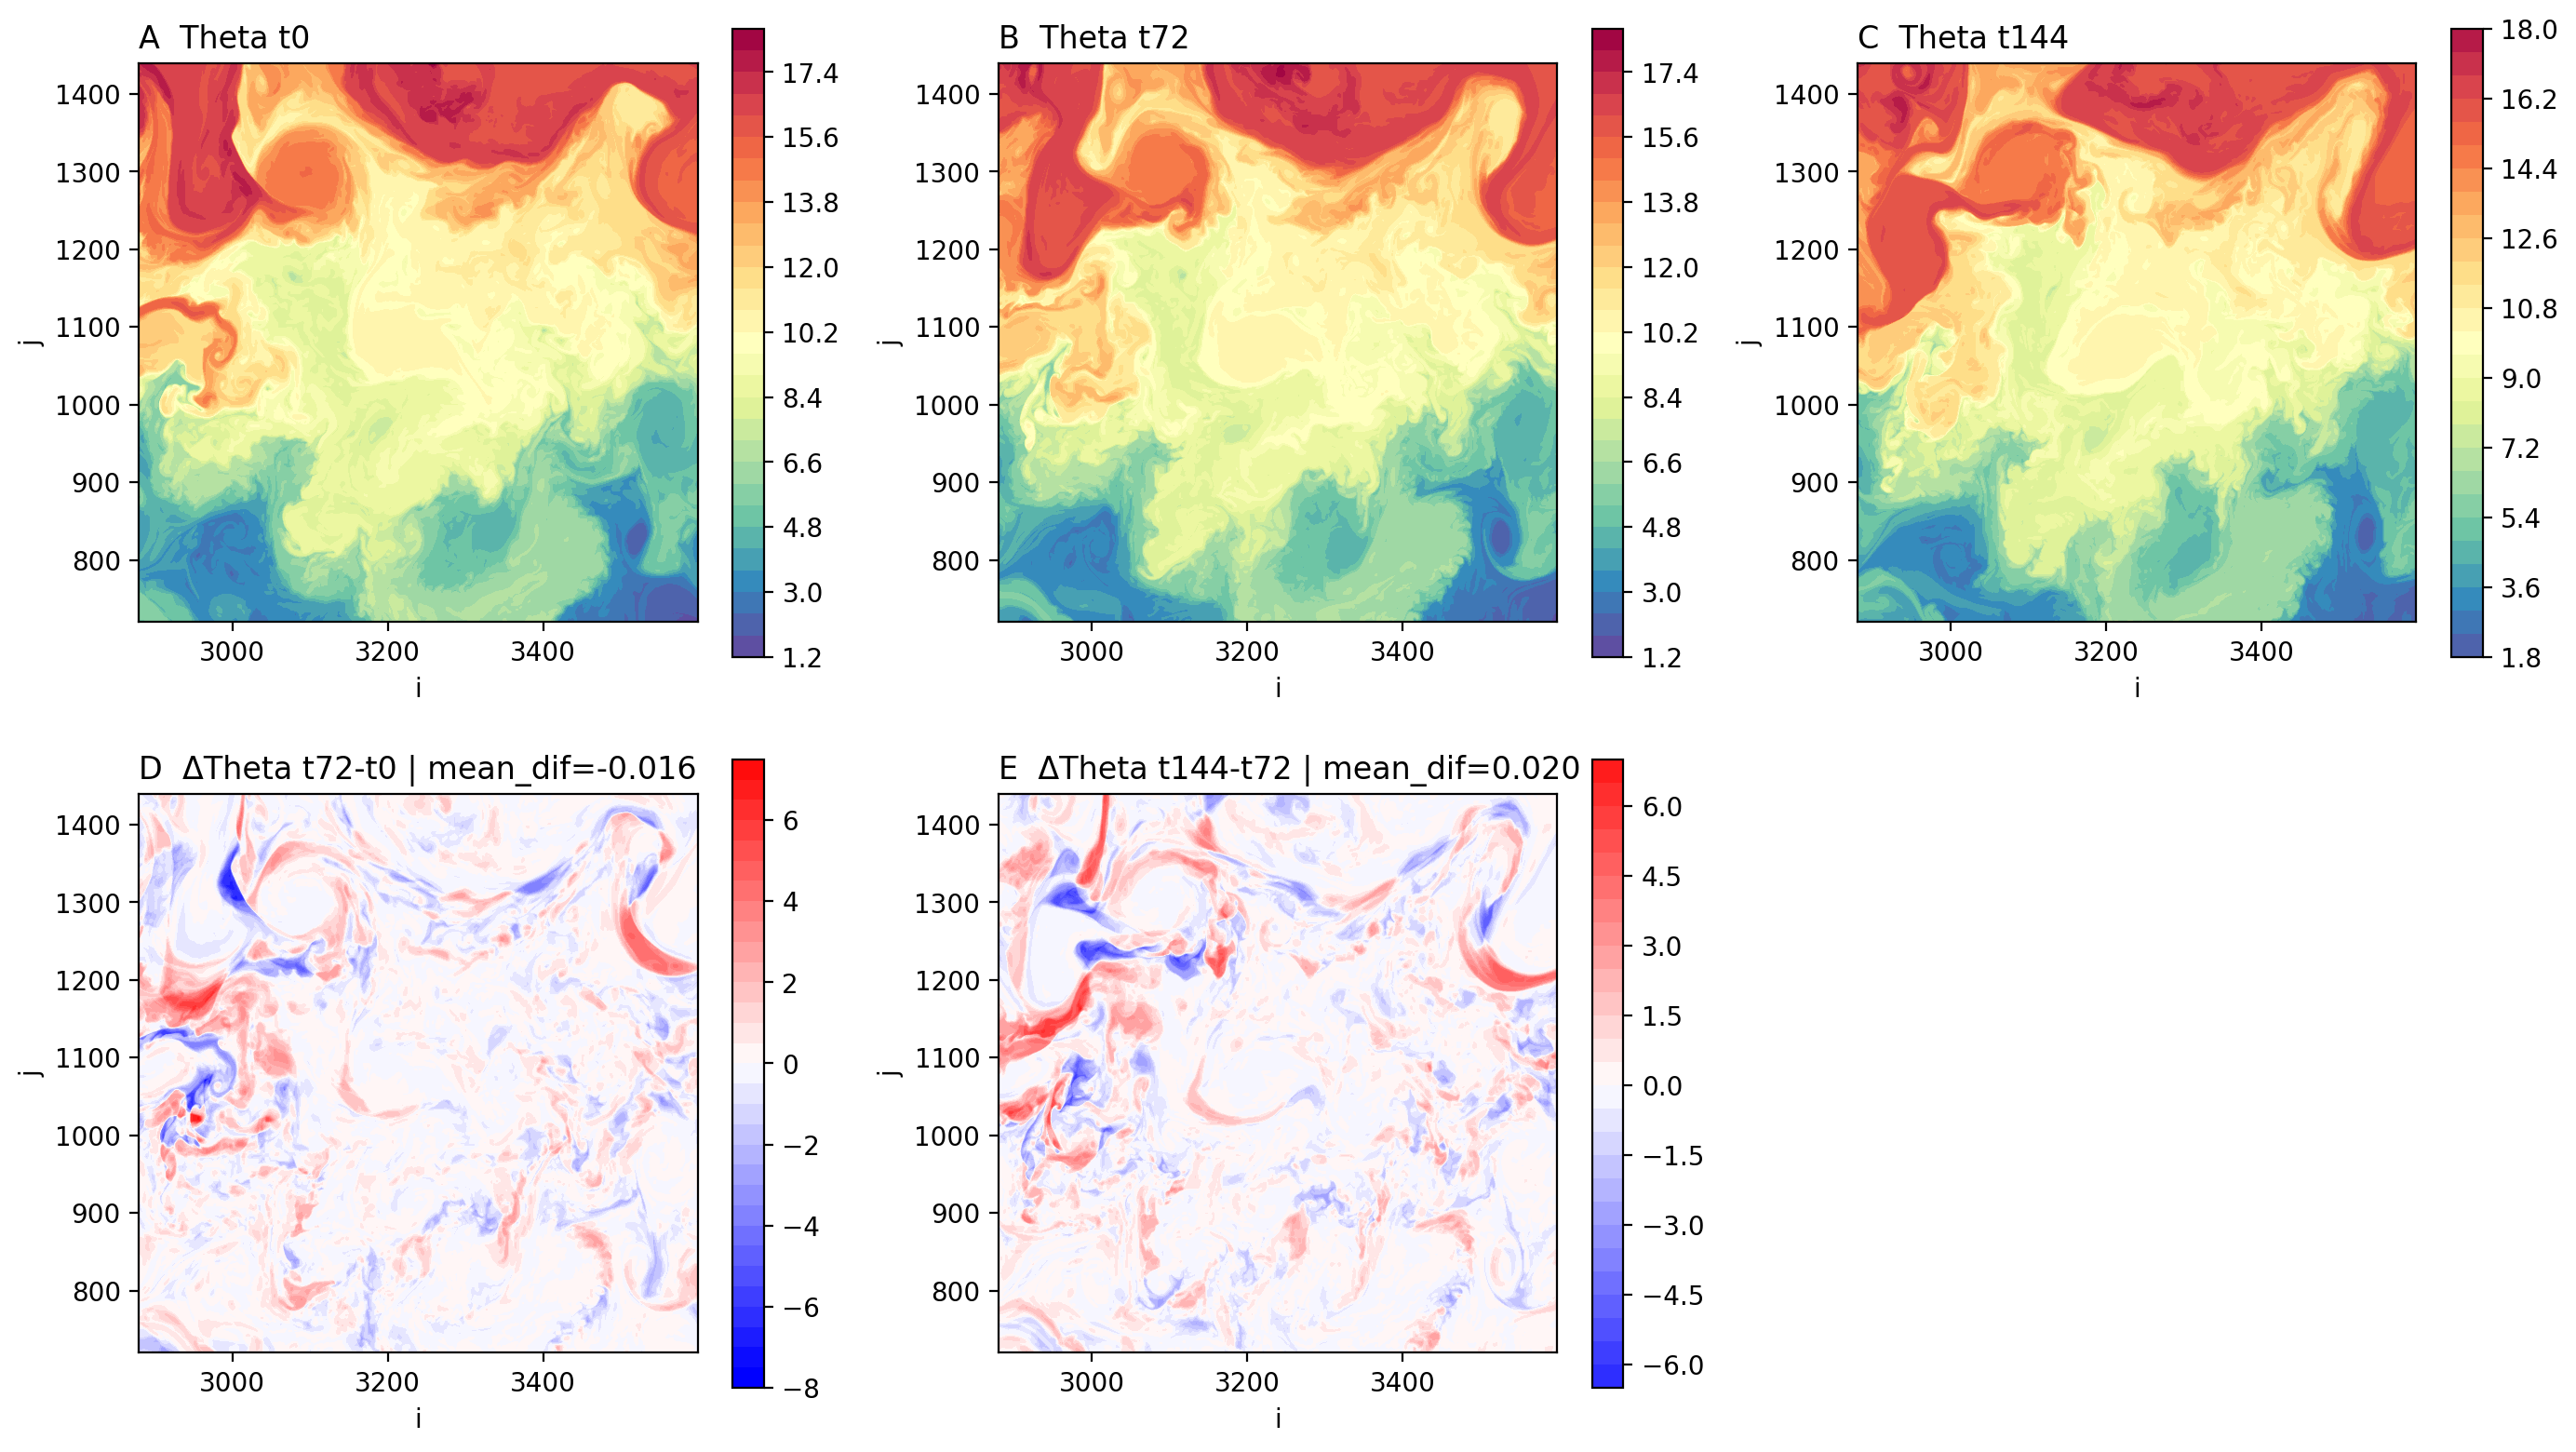

In [8]:
vars = ['Theta']
colormaps = {'Theta': 'Spectral_r', 'Salt': 'viridis', 'U': 'bwr', 'V': 'bwr'}
data_stride = 72
time_0 = 0

for var in vars:
    print(f"Generating plots for {var}...")

    t0 = time_0
    t1 = time_0 + data_stride
    t2 = time_0 + 2 * data_stride

    if t2 >= len(llc_sub.time):
        raise ValueError(f"time_0 + 2*data_stride = {t2}, but only {len(llc_sub.time)} times available")

    field0 = llc_sub[var].isel(time=t0)
    field1 = llc_sub[var].isel(time=t1)
    field2 = llc_sub[var].isel(time=t2)

    diff10 = field1 - field0
    diff21 = field2 - field1

    mean_dif_10 = float(diff10.mean(skipna=True).values)
    mean_dif_21 = float(diff21.mean(skipna=True).values)

    x = field0.coords.get('i', np.arange(field0.shape[-1]))
    y = field0.coords.get('j', np.arange(field0.shape[-2]))

    cmap = colormaps.get(var, 'viridis')
    diff_cmap = cmap if cmap in ['bwr', 'seismic', 'RdBu_r'] else 'bwr'

    # robust limits
    field_vals = np.concatenate([field0.values.ravel(),
                                 field1.values.ravel(),
                                 field2.values.ravel()])
    field_vals = field_vals[np.isfinite(field_vals)]

    if len(field_vals) == 0:
        continue

    vmin, vmax = np.nanmin(field_vals), np.nanmax(field_vals)

    diff_vals = np.concatenate([diff10.values.ravel(), diff21.values.ravel()])
    diff_vals = diff_vals[np.isfinite(diff_vals)]

    if len(diff_vals) == 0:
        continue

    diff_absmax = np.nanmax(np.abs(diff_vals))

    # --- NEW LANDSCAPE LAYOUT ---
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=200)

    # --- Row 1: fields ---
    cf = axes[0, 0].contourf(x, y, field0, cmap=cmap, vmin=vmin, vmax=vmax, levels=30)
    axes[0, 0].set_title(f'A  {var} t{t0}', loc='left', fontweight='bold')
    plt.colorbar(cf, ax=axes[0, 0])

    cf = axes[0, 1].contourf(x, y, field1, cmap=cmap, vmin=vmin, vmax=vmax, levels=30)
    axes[0, 1].set_title(f'B  {var} t{t1}', loc='left', fontweight='bold')
    plt.colorbar(cf, ax=axes[0, 1])

    cf = axes[0, 2].contourf(x, y, field2, cmap=cmap, vmin=vmin, vmax=vmax, levels=30)
    axes[0, 2].set_title(f'C  {var} t{t2}', loc='left', fontweight='bold')
    plt.colorbar(cf, ax=axes[0, 2])

    # --- Row 2: differences ---
    cf = axes[1, 0].contourf(x, y, diff10, cmap=diff_cmap,
                             vmin=-diff_absmax, vmax=diff_absmax, levels=30)
    axes[1, 0].set_title(
        f'D  Δ{var} t{t1}-t{t0} | mean_dif={mean_dif_10:.3f}',
        loc='left', fontweight='bold'
    )
    plt.colorbar(cf, ax=axes[1, 0])

    cf = axes[1, 1].contourf(x, y, diff21, cmap=diff_cmap,
                             vmin=-diff_absmax, vmax=diff_absmax, levels=30)
    axes[1, 1].set_title(
        f'E  Δ{var} t{t2}-t{t1} | mean_dif={mean_dif_21:.3f}',
        loc='left', fontweight='bold'
    )
    plt.colorbar(cf, ax=axes[1, 1])

    # empty panel (keeps layout clean)
    axes[1, 2].axis('off')

    # formatting
    for ax in axes.flat:
        if ax.has_data():
            ax.set_xlabel('i')
            ax.set_ylabel('j')
            ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

In [9]:
llc_sub = llc_patch_full.isel(time=slice(9240,9240+168),k=50)

Generating plots for Theta...


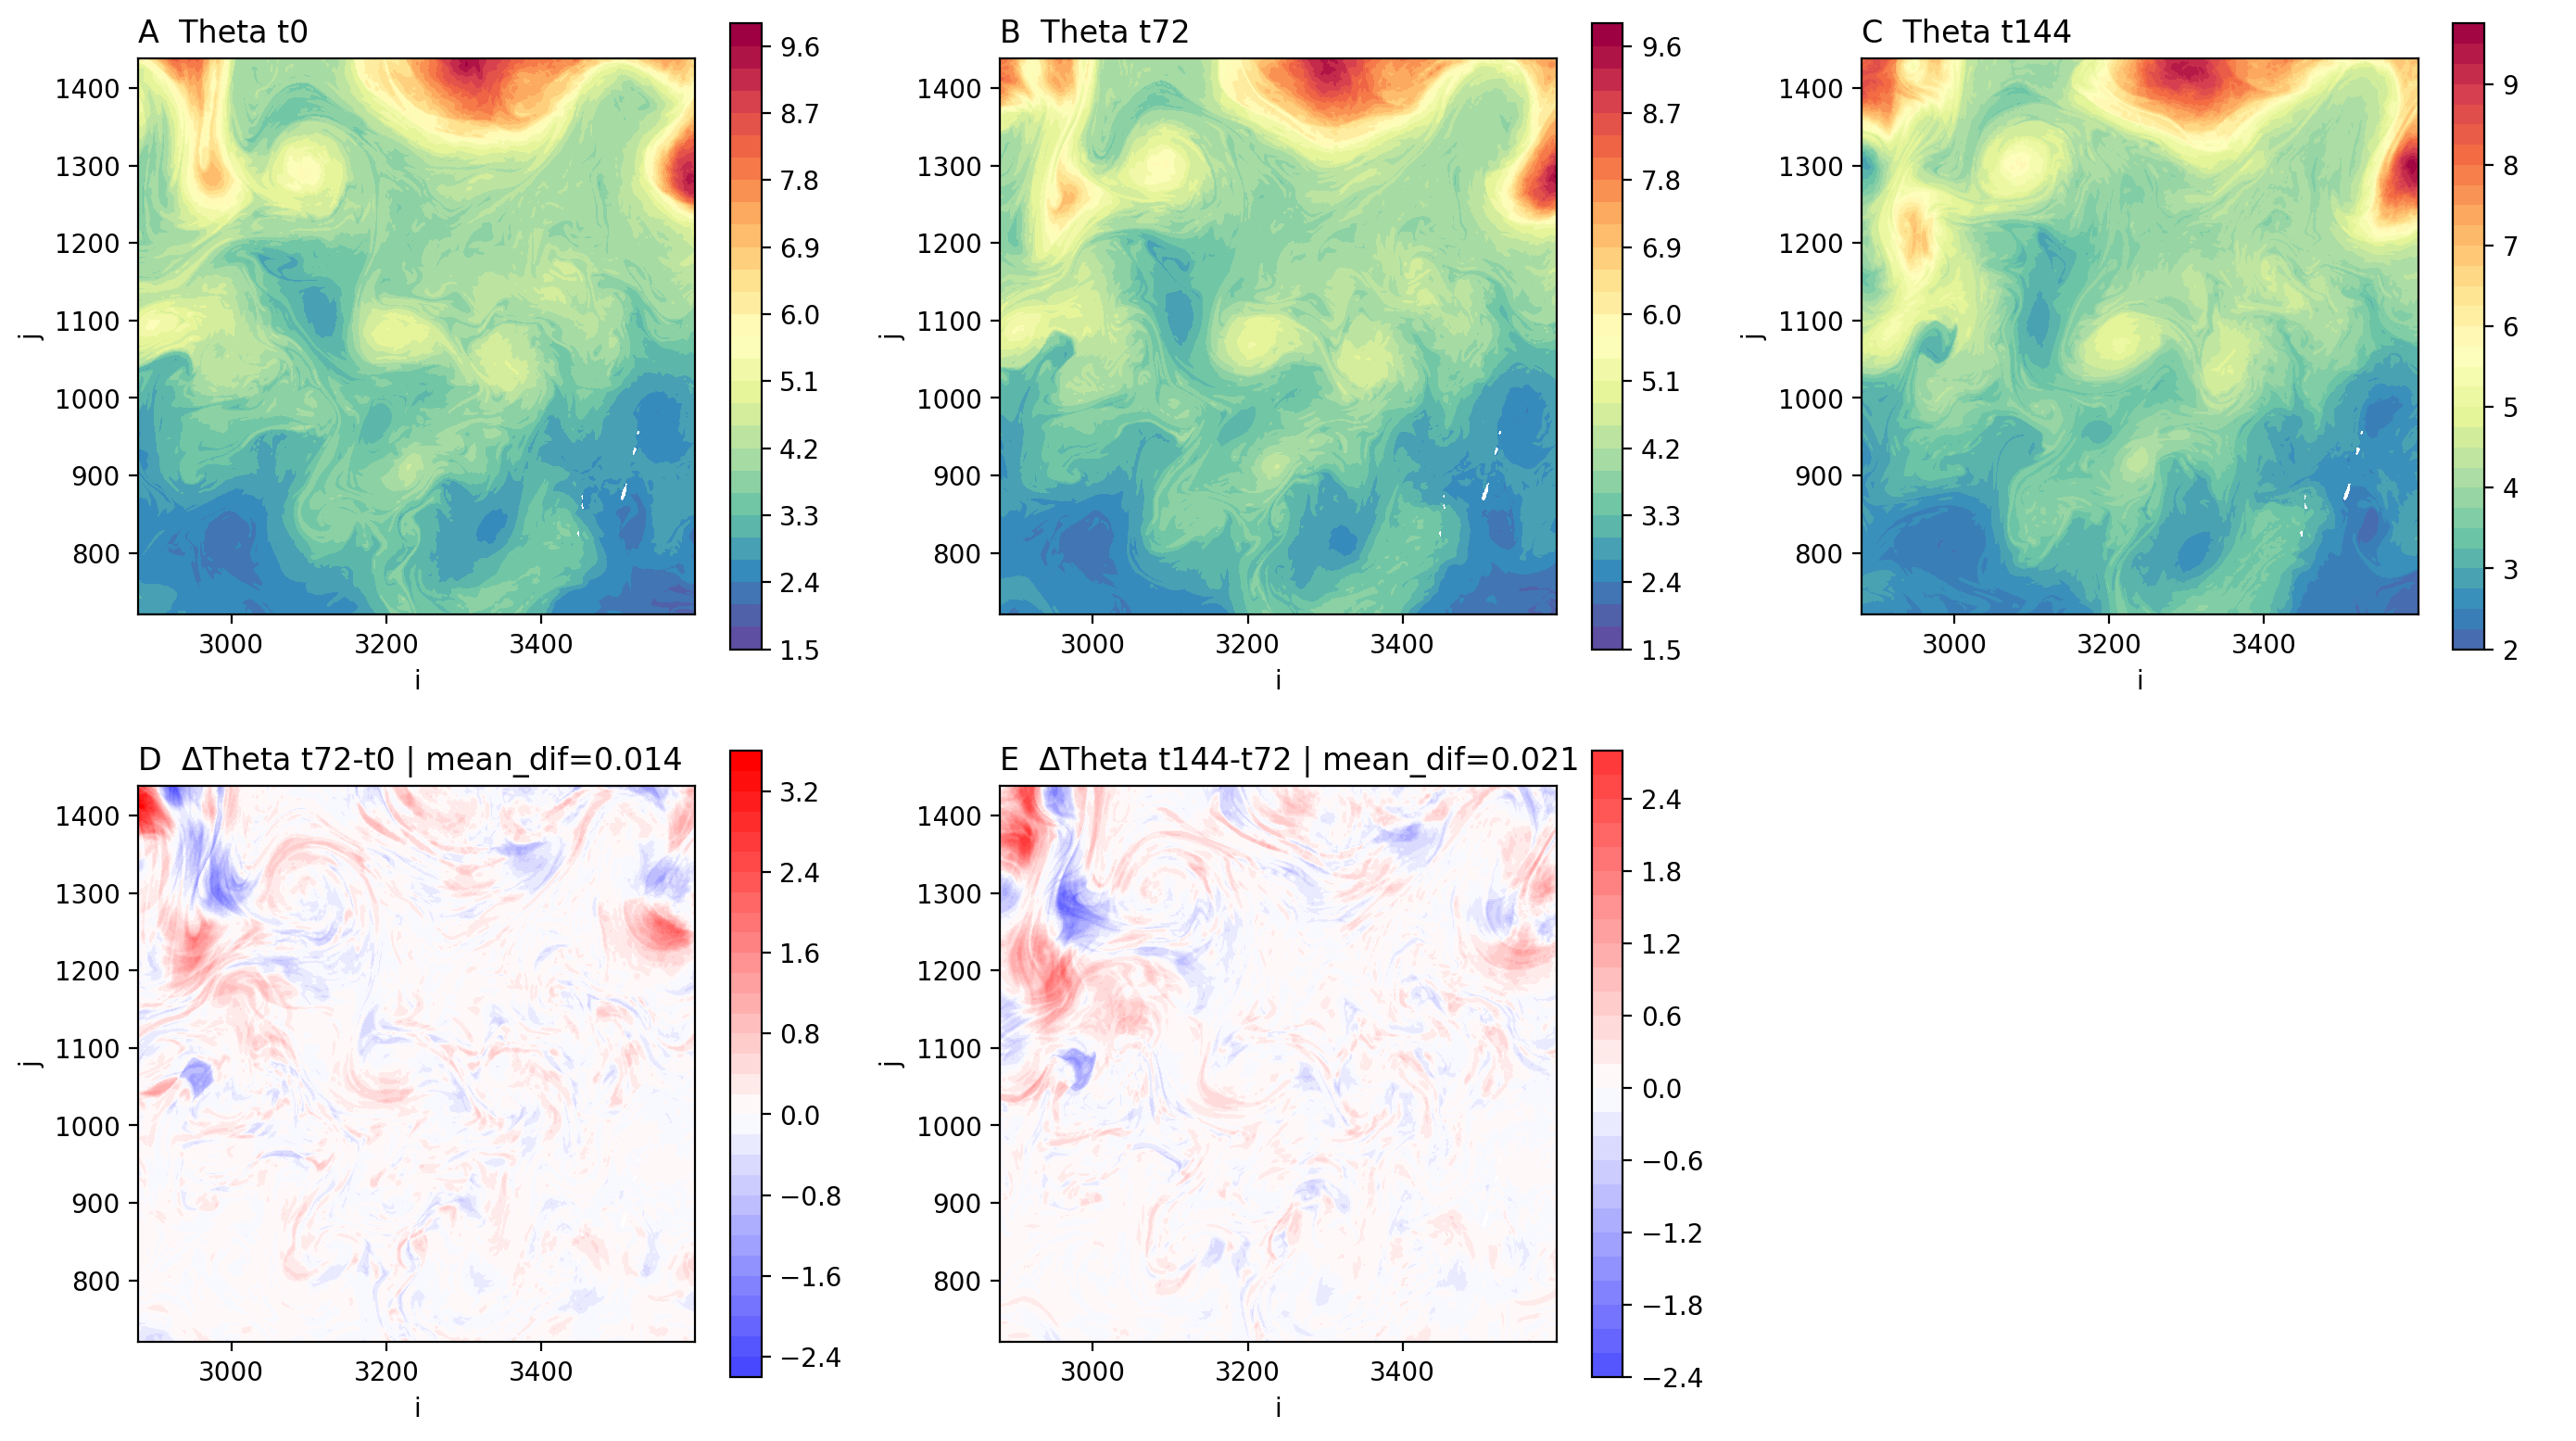

In [10]:
vars = ['Theta']
colormaps = {'Theta': 'Spectral_r', 'Salt': 'viridis', 'U': 'bwr', 'V': 'bwr'}
data_stride = 72
time_0 = 0

for var in vars:
    print(f"Generating plots for {var}...")

    t0 = time_0
    t1 = time_0 + data_stride
    t2 = time_0 + 2 * data_stride

    if t2 >= len(llc_sub.time):
        raise ValueError(f"time_0 + 2*data_stride = {t2}, but only {len(llc_sub.time)} times available")

    field0 = llc_sub[var].isel(time=t0)
    field1 = llc_sub[var].isel(time=t1)
    field2 = llc_sub[var].isel(time=t2)

    diff10 = field1 - field0
    diff21 = field2 - field1

    mean_dif_10 = float(diff10.mean(skipna=True).values)
    mean_dif_21 = float(diff21.mean(skipna=True).values)

    x = field0.coords.get('i', np.arange(field0.shape[-1]))
    y = field0.coords.get('j', np.arange(field0.shape[-2]))

    cmap = colormaps.get(var, 'viridis')
    diff_cmap = cmap if cmap in ['bwr', 'seismic', 'RdBu_r'] else 'bwr'

    # robust limits
    field_vals = np.concatenate([field0.values.ravel(),
                                 field1.values.ravel(),
                                 field2.values.ravel()])
    field_vals = field_vals[np.isfinite(field_vals)]

    if len(field_vals) == 0:
        continue

    vmin, vmax = np.nanmin(field_vals), np.nanmax(field_vals)

    diff_vals = np.concatenate([diff10.values.ravel(), diff21.values.ravel()])
    diff_vals = diff_vals[np.isfinite(diff_vals)]

    if len(diff_vals) == 0:
        continue

    diff_absmax = np.nanmax(np.abs(diff_vals))

    # --- NEW LANDSCAPE LAYOUT ---
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=200)

    # --- Row 1: fields ---
    cf = axes[0, 0].contourf(x, y, field0, cmap=cmap, vmin=vmin, vmax=vmax, levels=30)
    axes[0, 0].set_title(f'A  {var} t{t0}', loc='left', fontweight='bold')
    plt.colorbar(cf, ax=axes[0, 0])

    cf = axes[0, 1].contourf(x, y, field1, cmap=cmap, vmin=vmin, vmax=vmax, levels=30)
    axes[0, 1].set_title(f'B  {var} t{t1}', loc='left', fontweight='bold')
    plt.colorbar(cf, ax=axes[0, 1])

    cf = axes[0, 2].contourf(x, y, field2, cmap=cmap, vmin=vmin, vmax=vmax, levels=30)
    axes[0, 2].set_title(f'C  {var} t{t2}', loc='left', fontweight='bold')
    plt.colorbar(cf, ax=axes[0, 2])

    # --- Row 2: differences ---
    cf = axes[1, 0].contourf(x, y, diff10, cmap=diff_cmap,
                             vmin=-diff_absmax, vmax=diff_absmax, levels=30)
    axes[1, 0].set_title(
        f'D  Δ{var} t{t1}-t{t0} | mean_dif={mean_dif_10:.3f}',
        loc='left', fontweight='bold'
    )
    plt.colorbar(cf, ax=axes[1, 0])

    cf = axes[1, 1].contourf(x, y, diff21, cmap=diff_cmap,
                             vmin=-diff_absmax, vmax=diff_absmax, levels=30)
    axes[1, 1].set_title(
        f'E  Δ{var} t{t2}-t{t1} | mean_dif={mean_dif_21:.3f}',
        loc='left', fontweight='bold'
    )
    plt.colorbar(cf, ax=axes[1, 1])

    # empty panel (keeps layout clean)
    axes[1, 2].axis('off')

    # formatting
    for ax in axes.flat:
        if ax.has_data():
            ax.set_xlabel('i')
            ax.set_ylabel('j')
            ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

Generating mean difference plot for Theta...


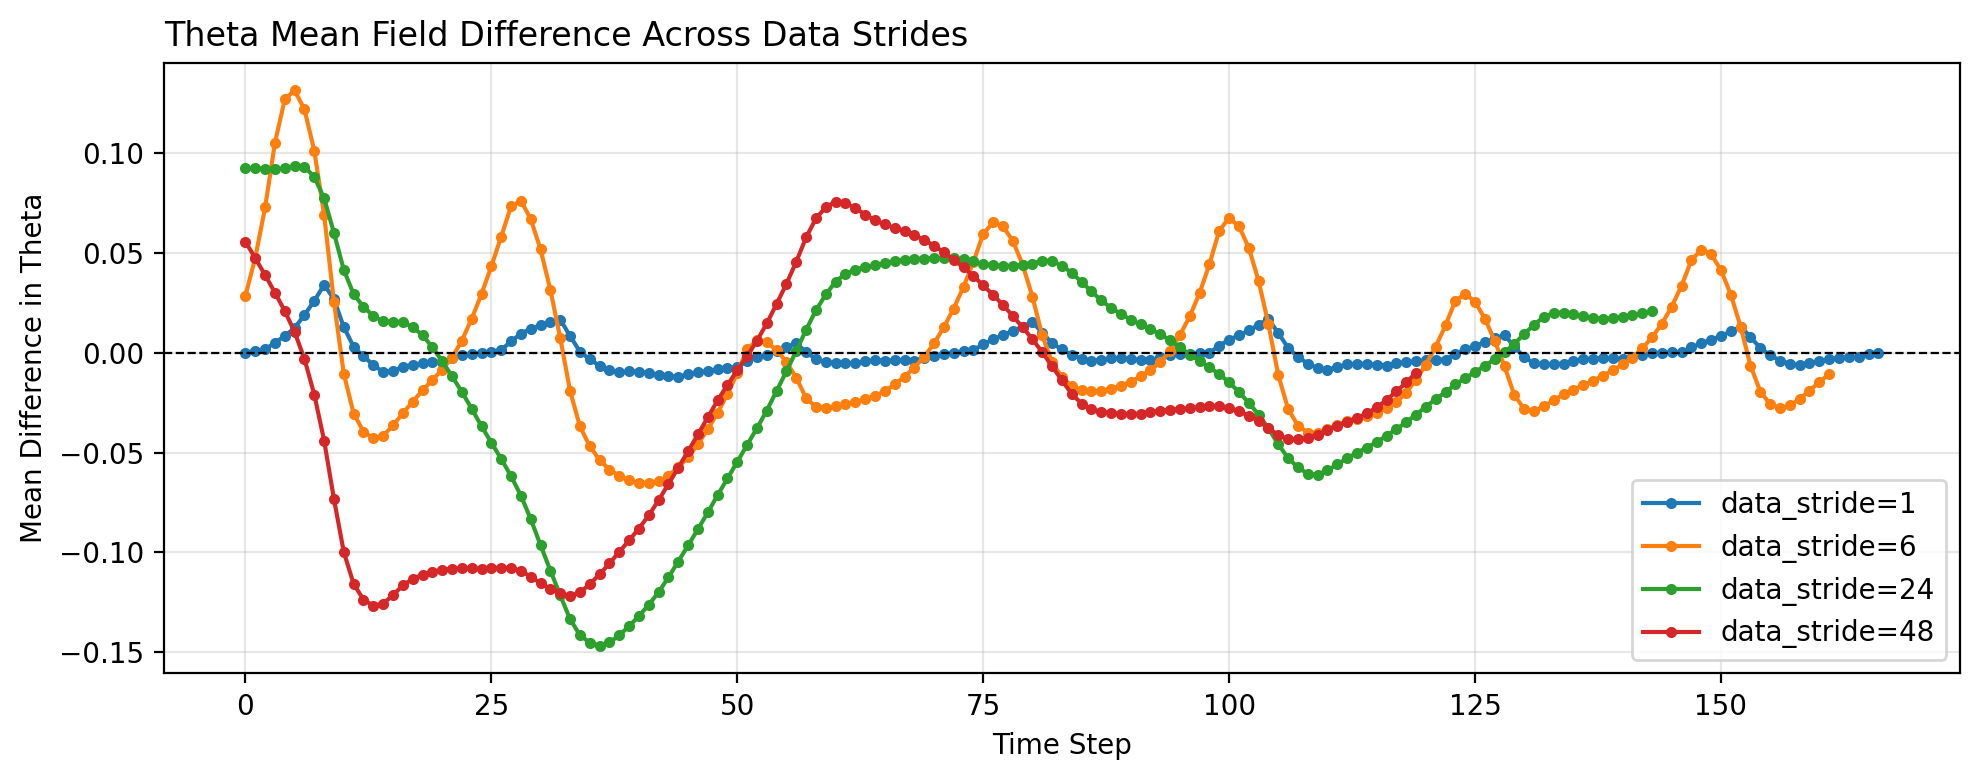

Generating mean difference plot for Salt...


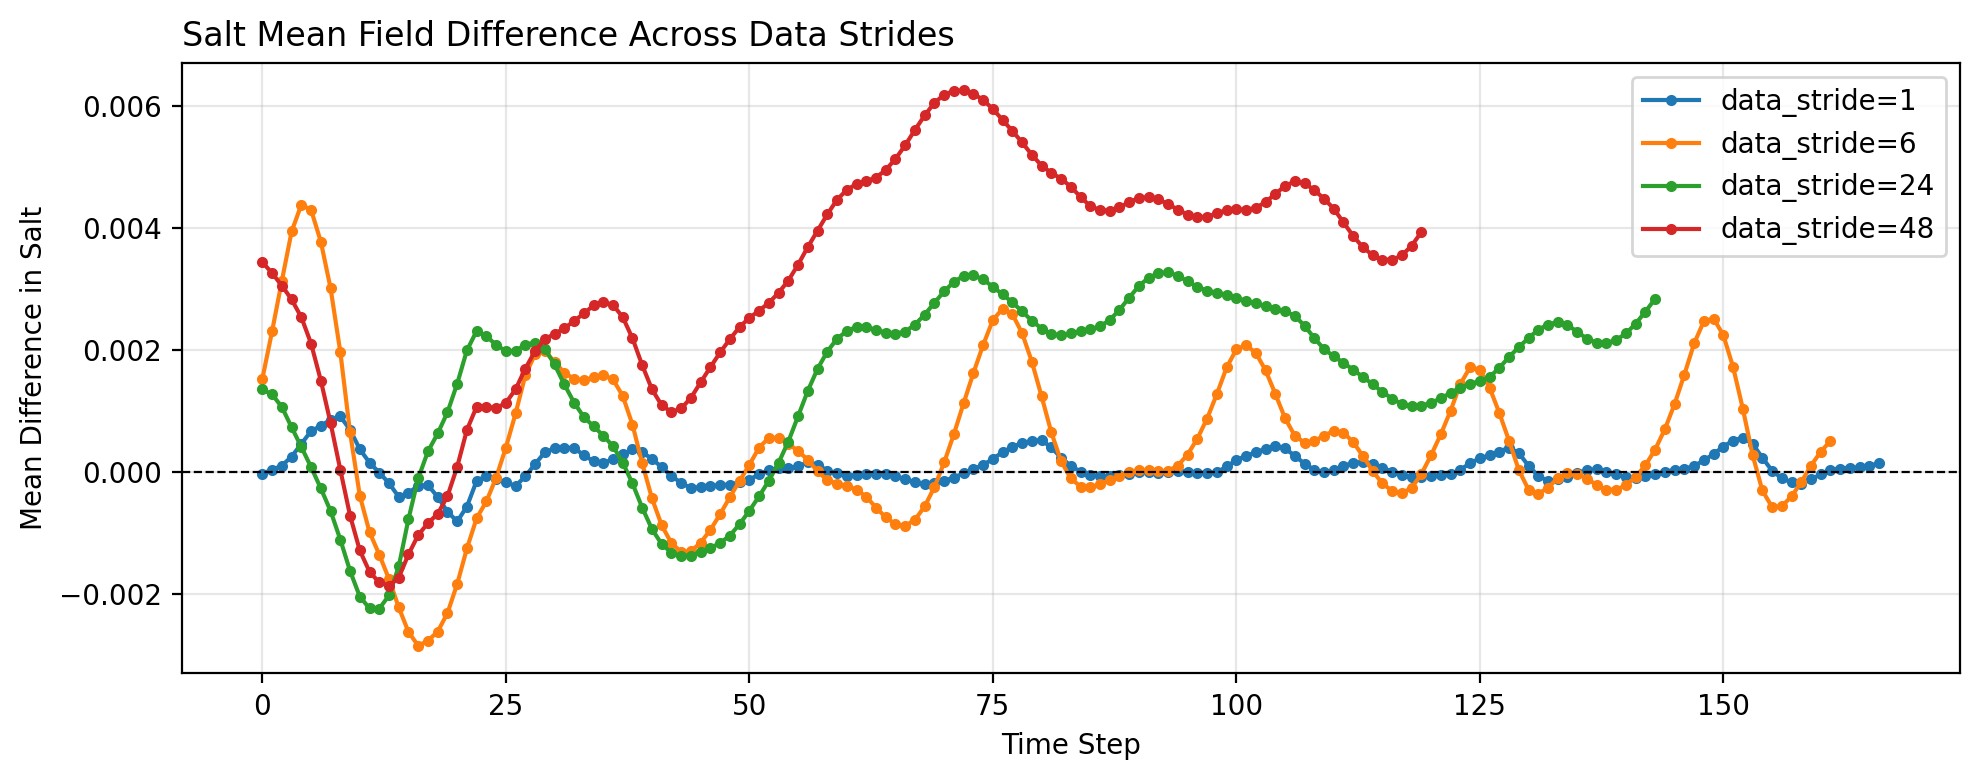

Generating mean difference plot for U...


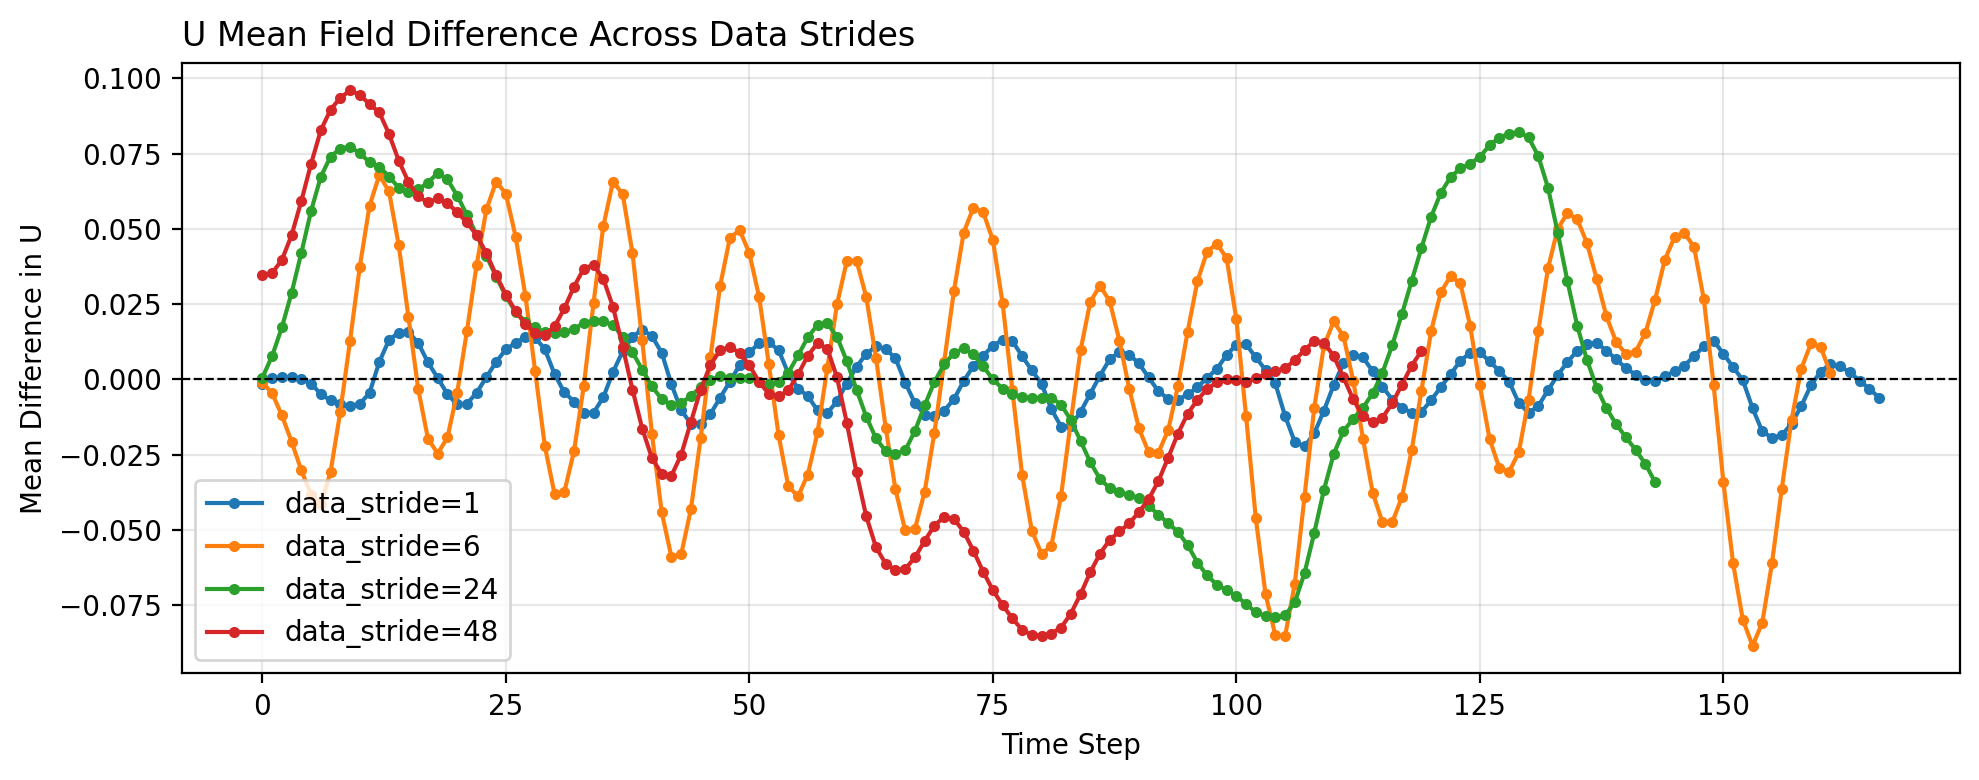

Generating mean difference plot for V...


KeyboardInterrupt: 

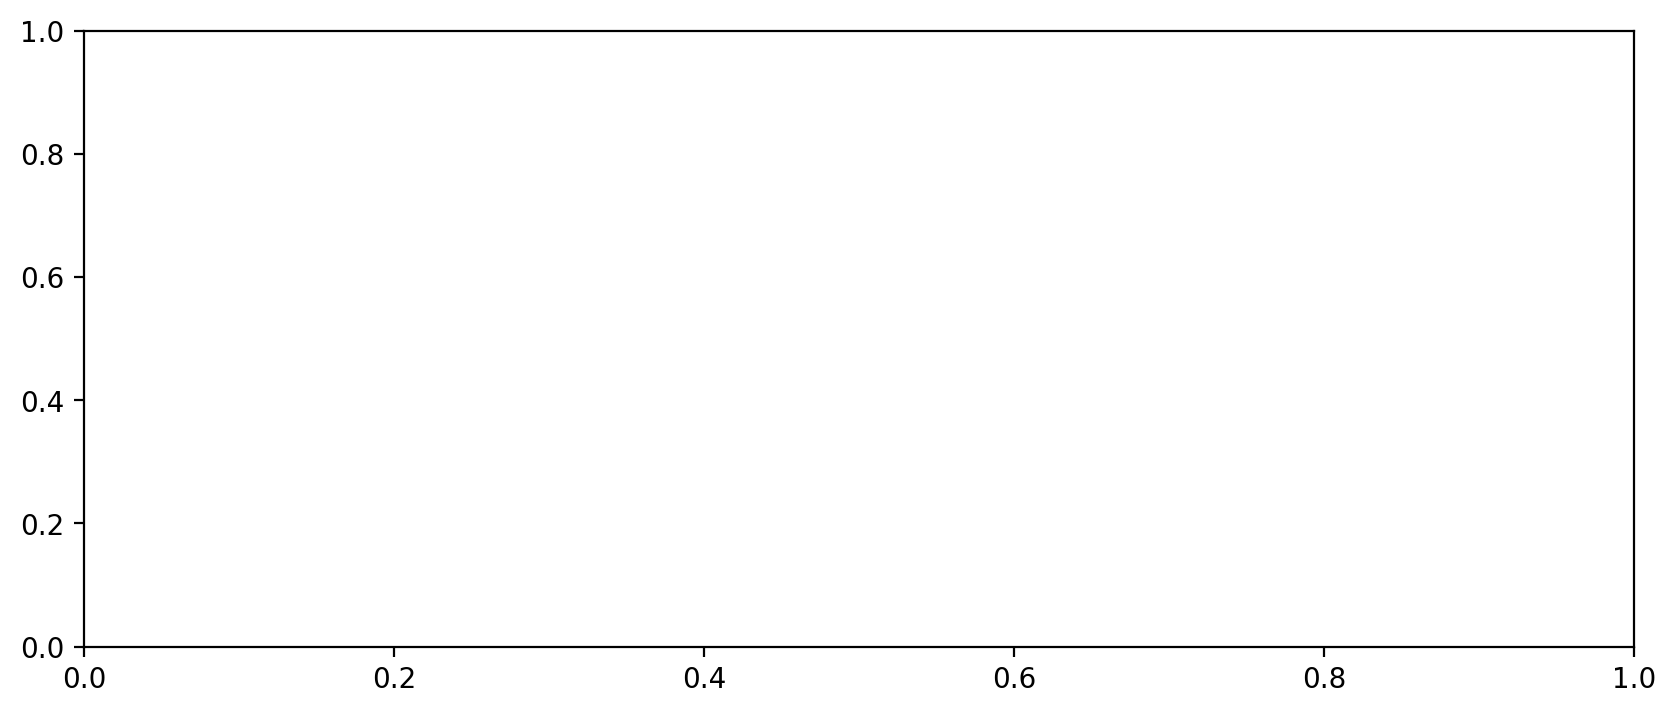

In [22]:
vars = ['Theta', 'Salt', 'U', 'V']
data_strides = [1, 6, 24, 48]

for var in vars:
    print(f"Generating mean difference plot for {var}...")

    n_times = len(llc_sub.time)
    time_indices = np.arange(n_times)

    fig, ax = plt.subplots(figsize=(10, 4), dpi=200)

    for data_stride in data_strides:
        mean_difs = np.full(n_times, np.nan)

        for t in range(n_times):
            t_next = t + data_stride

            if t_next < n_times:
                field_t = llc_sub[var].isel(time=t)
                field_next = llc_sub[var].isel(time=t_next)

                diff = field_next - field_t
                mean_difs[t] = float(diff.mean().values)

        ax.plot(time_indices, mean_difs, marker='o', linewidth=1.5, markersize=3,
                label=f'data_stride={data_stride}')

    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')

    ax.set_xlabel('Time Step')
    ax.set_ylabel(f'Mean Difference in {var}')
    ax.set_title(f'{var} Mean Field Difference Across Data Strides', fontweight='bold', loc='left')

    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Generating mean difference plot for Theta...


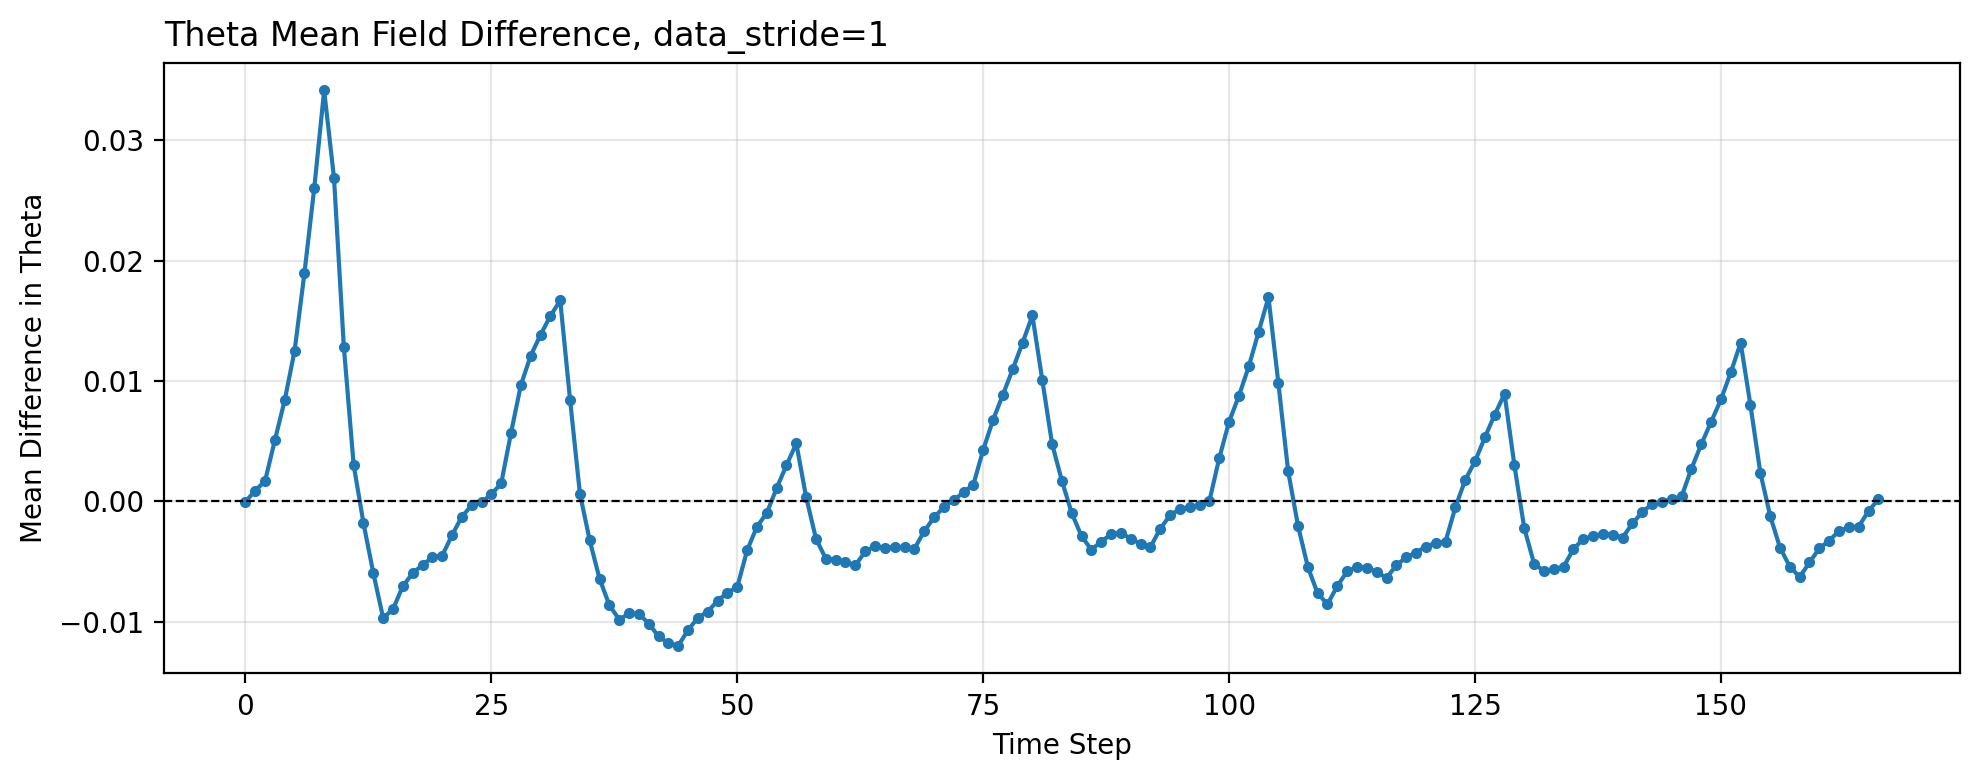

In [23]:
vars = ['Theta']
data_stride = 1

colormaps = {'Theta': 'Spectral_r', 'Salt': 'viridis', 'U': 'bwr', 'V': 'bwr'}

for var in vars:
    print(f"Generating mean difference plot for {var}...")

    n_times = len(llc_sub.time)
    time_indices = np.arange(n_times)

    mean_difs = np.full(n_times, np.nan)

    for t in range(n_times):
        t_next = t + data_stride

        if t_next < n_times:
            field_t = llc_sub[var].isel(time=t)
            field_next = llc_sub[var].isel(time=t_next)

            diff = field_next - field_t
            mean_difs[t] = float(diff.mean().values)

    fig, ax = plt.subplots(figsize=(10, 4), dpi=200)

    ax.plot(time_indices, mean_difs, marker='o', linewidth=1.5, markersize=3)

    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')

    ax.set_xlabel('Time Step')
    ax.set_ylabel(f'Mean Difference in {var}')
    ax.set_title(f'{var} Mean Field Difference, data_stride={data_stride}', fontweight='bold', loc='left')

    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Generating mean difference plot for Theta...


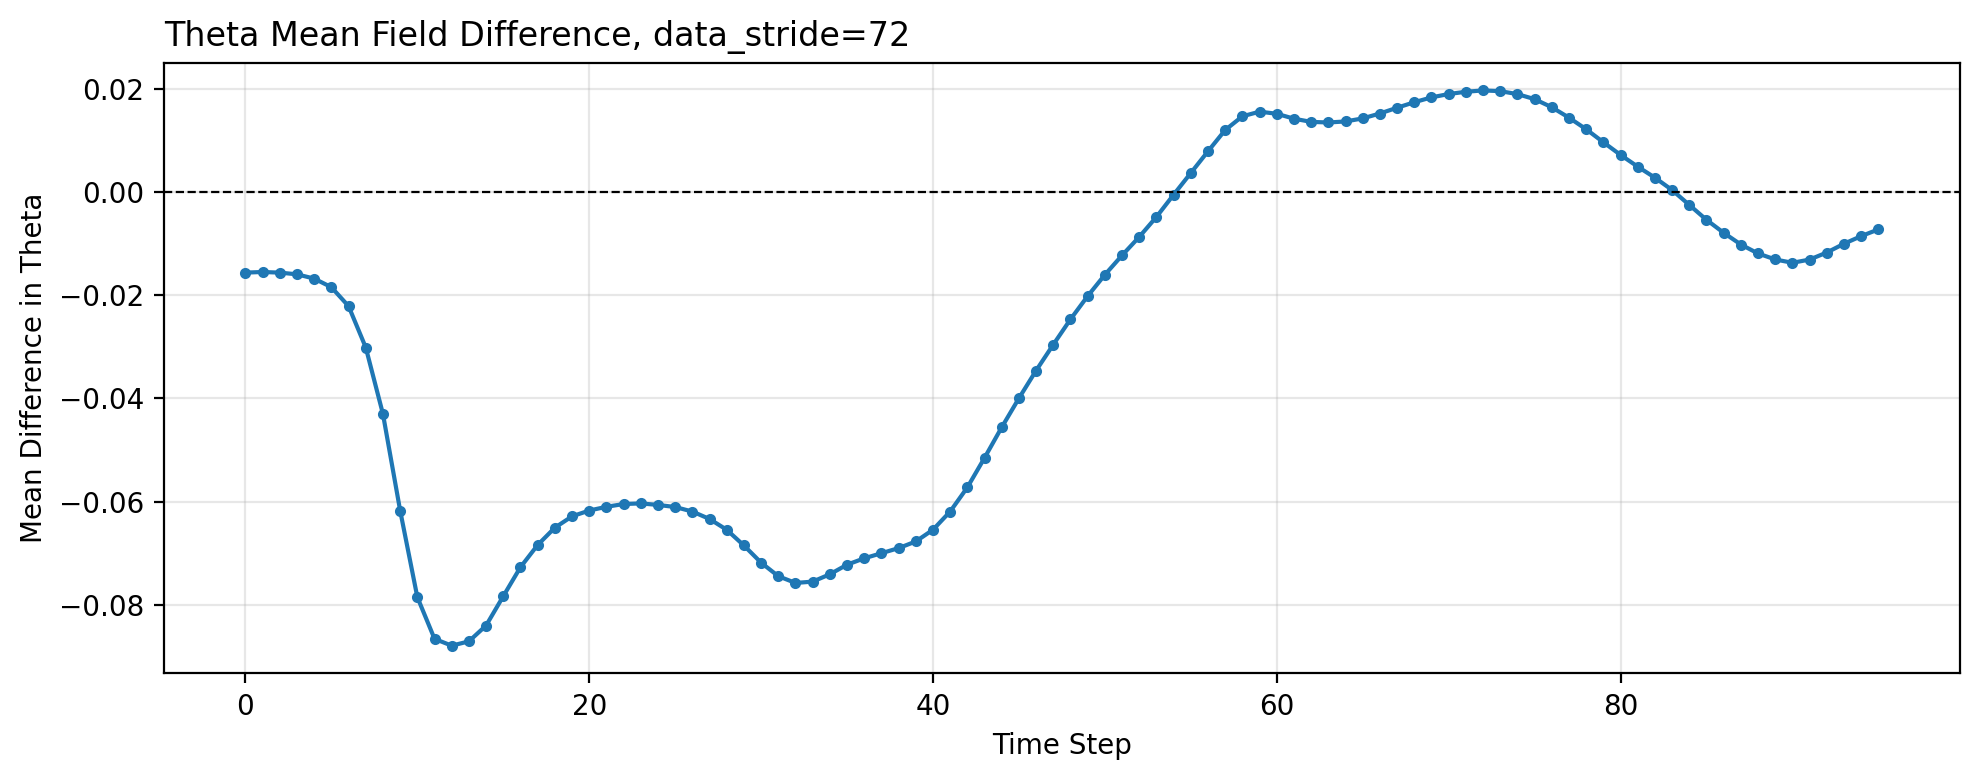

In [24]:
vars = ['Theta']
data_stride = 72

colormaps = {'Theta': 'Spectral_r', 'Salt': 'viridis', 'U': 'bwr', 'V': 'bwr'}

for var in vars:
    print(f"Generating mean difference plot for {var}...")

    n_times = len(llc_sub.time)
    time_indices = np.arange(n_times)

    mean_difs = np.full(n_times, np.nan)

    for t in range(n_times):
        t_next = t + data_stride

        if t_next < n_times:
            field_t = llc_sub[var].isel(time=t)
            field_next = llc_sub[var].isel(time=t_next)

            diff = field_next - field_t
            mean_difs[t] = float(diff.mean().values)

    fig, ax = plt.subplots(figsize=(10, 4), dpi=200)

    ax.plot(time_indices, mean_difs, marker='o', linewidth=1.5, markersize=3)

    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')

    ax.set_xlabel('Time Step')
    ax.set_ylabel(f'Mean Difference in {var}')
    ax.set_title(f'{var} Mean Field Difference, data_stride={data_stride}', fontweight='bold', loc='left')

    ax.grid(True, alpha=0.3)

    plt.tight_layout()